In [1]:
import faiss
import torch
import numpy as np
from tqdm import tqdm
from typing import Tuple
from torch.utils.data.dataset import Subset
from torch.utils.data import DataLoader, Dataset
import visualizations
import sys
import multiprocessing
from datetime import datetime
from datasets.test_dataset import TestDataset

In [3]:
model.to("cuda")

GeoLocalizationNet(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0):

In [3]:

# Compute R@1, R@5, R@10, R@20
RECALL_VALUES = [1, 5, 10, 20]


def test(eval_ds: Dataset, model: torch.nn.Module,
         num_preds_to_save: int = 0) -> Tuple[np.ndarray, str]:
    """Compute descriptors of the given dataset and compute the recalls."""
    
    model = model.eval()
    with torch.no_grad():
        print("Extracting database descriptors for evaluation/testing")
        database_subset_ds = Subset(eval_ds, list(range(eval_ds.database_num)))
        database_dataloader = DataLoader(dataset=database_subset_ds,
                                         batch_size=32, pin_memory=True)
        all_descriptors = np.empty((len(eval_ds), 2048), dtype="float32")
        for images, indices in tqdm(database_dataloader, ncols=100):
            descriptors = model(images.to("cuda"))
            descriptors = descriptors.cpu().numpy()
            all_descriptors[indices.numpy(), :] = descriptors
        
        print("Extracting queries descriptors for evaluation/testing using batch size 1")
        queries_infer_batch_size = 1
        queries_subset_ds = Subset(eval_ds, list(range(eval_ds.database_num, eval_ds.database_num+eval_ds.queries_num)))
        queries_dataloader = DataLoader(dataset=queries_subset_ds,
                                        batch_size=queries_infer_batch_size, pin_memory=True)
        for images, indices in tqdm(queries_dataloader, ncols=100):
            descriptors = model(images.to("cuda"))
            descriptors = descriptors.cpu().numpy()
            all_descriptors[indices.numpy(), :] = descriptors
    
    queries_descriptors = all_descriptors[eval_ds.database_num:]
    database_descriptors = all_descriptors[:eval_ds.database_num]
    
    # Use a kNN to find predictions
    faiss_index = faiss.IndexFlatL2(2048)
    faiss_index.add(database_descriptors)
    del database_descriptors, all_descriptors
    
    print("Calculating recalls")
    _, predictions = faiss_index.search(queries_descriptors, max(RECALL_VALUES))
    
    #### For each query, check if the predictions are correct
    positives_per_query = eval_ds.get_positives()
    recalls = np.zeros(len(RECALL_VALUES))
    for query_index, preds in enumerate(predictions):
        for i, n in enumerate(RECALL_VALUES):
            if np.any(np.in1d(preds[:n], positives_per_query[query_index])):
                recalls[i:] += 1
                break
    
    # Divide by queries_num and multiply by 100, so the recalls are in percentages
    recalls = recalls / eval_ds.queries_num * 100
    recalls_str = ", ".join([f"R@{val}: {rec:.1f}" for val, rec in zip(RECALL_VALUES, recalls)])
    
    # Save visualizations of predictions
    if num_preds_to_save != 0:
        # For each query save num_preds_to_save predictions
        visualizations.save_preds(predictions[:, :num_preds_to_save], eval_ds, "Visualizations_folder", False)
    
    return recalls, recalls_str


In [ ]:
torch.backends.cudnn.benchmark = True  # Provides a speedup

start_time = datetime.now()
output_folder = f"logs/Visualizations_folder/{start_time.strftime('%Y-%m-%d_%H-%M-%S')}"
print(" ".join(sys.argv))
print(f"The outputs are being saved in {output_folder}")

print(f"There are {torch.cuda.device_count()} GPUs and {multiprocessing.cpu_count()} CPUs.")

model = model.to("cuda")

test_ds = TestDataset("small/test/database", queries_folder="small/test/queries_v1")

recalls, recalls_str = test(test_ds, model, 3)
print(f"{test_ds}: {recalls_str}")


In [10]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Compute R@1, R@5, R@10, R@20
RECALL_VALUES = [1, 5, 10, 20]

def test(eval_ds: Dataset, model: torch.nn.Module, num_preds_to_save: int = 0):
    """Compute descriptors of the given dataset and compute the recalls."""
    
    model = model.eval()
    with torch.no_grad():
        print("Extracting database descriptors for evaluation/testing")
        database_subset_ds = Subset(eval_ds, list(range(eval_ds.database_num)))
        database_dataloader = DataLoader(dataset=database_subset_ds, batch_size=32, pin_memory=True)
        all_descriptors = np.empty((len(eval_ds), 2048), dtype="float32")
        for images, indices in tqdm(database_dataloader, ncols=100):
            descriptors = model(images.to("cuda"))
            descriptors = descriptors.cpu().numpy()
            all_descriptors[indices.numpy(), :] = descriptors
        
        print("Extracting queries descriptors for evaluation/testing using batch size 1")
        queries_infer_batch_size = 1
        queries_subset_ds = Subset(eval_ds, list(range(eval_ds.database_num, eval_ds.database_num+eval_ds.queries_num)))
        queries_dataloader = DataLoader(dataset=queries_subset_ds, batch_size=queries_infer_batch_size, pin_memory=True)
        for images, indices in tqdm(queries_dataloader, ncols=100):
            descriptors = model(images.to("cuda"))
            descriptors = descriptors.cpu().numpy()
            all_descriptors[indices.numpy(), :] = descriptors
    
    queries_descriptors = all_descriptors[eval_ds.database_num:]
    database_descriptors = all_descriptors[:eval_ds.database_num]
    
    # Use a kNN to find predictions
    faiss_index = faiss.IndexFlatL2(2048)
    faiss_index.add(database_descriptors)
    del database_descriptors, all_descriptors
    
    print("Calculating recalls")
    _, predictions = faiss_index.search(queries_descriptors, max(RECALL_VALUES))
    
    # Compute recall
    positives_per_query = eval_ds.get_positives()
    recalls = np.zeros(len(RECALL_VALUES))
    all_positives = 0
    all_retrieved = 0
    all_relevant_retrieved = 0
    true_labels = []
    pred_labels = []
    
    for query_index, preds in enumerate(predictions):
        relevant_retrieved = np.in1d(preds, positives_per_query[query_index]).sum()
        all_positives += len(positives_per_query[query_index])
        all_retrieved += len(preds)
        all_relevant_retrieved += relevant_retrieved

        # Binary labels for each query
        true_labels.extend([1] * len(positives_per_query[query_index]) + [0] * (len(preds) - len(positives_per_query[query_index])))
        pred_labels.extend(np.in1d(preds, positives_per_query[query_index]).astype(int).tolist())
        
        for i, n in enumerate(RECALL_VALUES):
            if np.any(np.in1d(preds[:n], positives_per_query[query_index])):
                recalls[i:] += 1
                break
    
    # Divide by queries_num and multiply by 100, so the recalls are in percentages
    recalls = recalls / eval_ds.queries_num * 100
    recalls_str = ", ".join([f"R@{val}: {rec:.1f}" for val, rec in zip(RECALL_VALUES, recalls)])
    
    # Compute additional metrics
    precision = precision_score(true_labels, pred_labels)
    accuracy = accuracy_score(true_labels, pred_labels)
    f1 = f1_score(true_labels, pred_labels)
    conf_matrix = confusion_matrix(true_labels, pred_labels)
    auc = roc_auc_score(true_labels, pred_labels)
    
    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()
    
    print(f"Precision: {precision:.2f}")
    print(f"Accuracy: {accuracy:.2f}")
    print(f"F1 Score: {f1:.2f}")
    print(f"AUC: {auc:.2f}")
    
    # Save visualizations of predictions
    if num_preds_to_save != 0:
        visualizations.save_preds(predictions[:, :num_preds_to_save], eval_ds, "Visualizations_folder", False)
    
    return recalls, recalls_str

# Assuming you have the Dataset and DataLoader set up as in your original code
# And assuming `model` is your trained model
test_ds = TestDataset("small/test", queries_folder="queries_v1")
recalls, recalls_str = test(test_ds, model, 3)
print(recalls_str)


Extracting database descriptors for evaluation/testing


100%|█████████████████████████████████████████████████████████████| 850/850 [10:09<00:00,  1.39it/s]


Extracting queries descriptors for evaluation/testing using batch size 1


100%|███████████████████████████████████████████████████████████| 1000/1000 [00:50<00:00, 19.72it/s]


Calculating recalls


ValueError: Found input variables with inconsistent numbers of samples: [21347, 20000]

In [5]:
test_ds = TestDataset("small/test", queries_folder="queries_v1")

model = model.eval()
with torch.no_grad():
    print("Extracting database descriptors for evaluation/testing")
    database_subset_ds = Subset(test_ds, list(range(test_ds.database_num)))
    database_dataloader = DataLoader(dataset=database_subset_ds, batch_size=32, pin_memory=True)
    all_descriptors = np.empty((len(test_ds), 2048), dtype="float32")
    for images, indices in tqdm(database_dataloader, ncols=100):
        descriptors = model(images.to("cuda"))
        descriptors = descriptors.cpu().numpy()
        all_descriptors[indices.numpy(), :] = descriptors
    
    print("Extracting queries descriptors for evaluation/testing using batch size 1")
    queries_infer_batch_size = 1
    queries_subset_ds = Subset(test_ds, list(range(test_ds.database_num, test_ds.database_num+test_ds.queries_num)))
    queries_dataloader = DataLoader(dataset=queries_subset_ds, batch_size=queries_infer_batch_size, pin_memory=True)
    for images, indices in tqdm(queries_dataloader, ncols=100):
        descriptors = model(images.to("cuda"))
        descriptors = descriptors.cpu().numpy()
        all_descriptors[indices.numpy(), :] = descriptors

queries_descriptors = all_descriptors[test_ds.database_num:]
database_descriptors = all_descriptors[:test_ds.database_num]

Extracting database descriptors for evaluation/testing


  0%|▎                                                              | 4/850 [00:14<47:33,  3.37s/it]

Extracting database descriptors for evaluation/testing


100%|█████████████████████████████████████████████████████████████| 850/850 [32:36<00:00,  2.30s/it]


Extracting queries descriptors for evaluation/testing using batch size 1


100%|███████████████████████████████████████████████████████████| 1000/1000 [03:20<00:00,  5.00it/s]


Calculating recalls


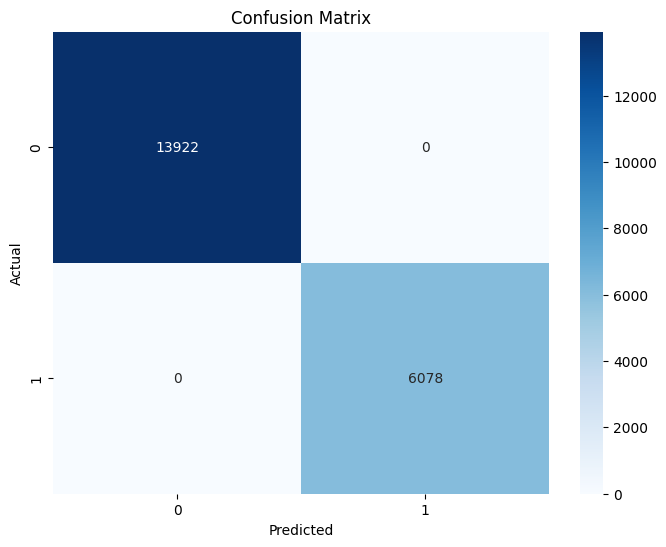

Precision: 1.00
Accuracy: 1.00
F1 Score: 1.00
AUC: 1.00


Saving preds in Visualizations_folder: 100%|█| 1000/1000 [04:06<00:00,  4.05it/s

R@1: 77.0, R@5: 84.0, R@10: 87.3, R@20: 89.2


In [4]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
import faiss

# Compute R@1, R@5, R@10, R@20
RECALL_VALUES = [1, 5, 10, 20]

def test(eval_ds, model, num_preds_to_save):
    """Compute descriptors of the given dataset and compute the recalls."""
    
    model = model.eval()
    with torch.no_grad():
        print("Extracting database descriptors for evaluation/testing")
        database_subset_ds = Subset(test_ds, list(range(test_ds.database_num)))
        database_dataloader = DataLoader(dataset=database_subset_ds, batch_size=32, pin_memory=True)
        all_descriptors = np.empty((len(test_ds), 2048), dtype="float32")
        for images, indices in tqdm(database_dataloader, ncols=100):
            descriptors = model(images.to("cuda"))
            descriptors = descriptors.cpu().numpy()
            all_descriptors[indices.numpy(), :] = descriptors
        
        print("Extracting queries descriptors for evaluation/testing using batch size 1")
        queries_infer_batch_size = 1
        queries_subset_ds = Subset(test_ds, list(range(test_ds.database_num, test_ds.database_num+test_ds.queries_num)))
        queries_dataloader = DataLoader(dataset=queries_subset_ds, batch_size=queries_infer_batch_size, pin_memory=True)
        for images, indices in tqdm(queries_dataloader, ncols=100):
            descriptors = model(images.to("cuda"))
            descriptors = descriptors.cpu().numpy()
            all_descriptors[indices.numpy(), :] = descriptors

    queries_descriptors = all_descriptors[test_ds.database_num:]
    database_descriptors = all_descriptors[:test_ds.database_num]
    # Use a kNN to find predictions
    faiss_index = faiss.IndexFlatL2(2048)
    faiss_index.add(database_descriptors)
    del database_descriptors, all_descriptors
    
    print("Calculating recalls")
    _, predictions = faiss_index.search(queries_descriptors, max(RECALL_VALUES))
    
    # Compute recall
    positives_per_query = eval_ds.get_positives()
    recalls = np.zeros(len(RECALL_VALUES))
    true_labels = []
    pred_labels = []
    
    for query_index, preds in enumerate(predictions):
        true_positive_set = set(positives_per_query[query_index])
        
        # Binary labels for each prediction
        binary_labels = np.in1d(preds, positives_per_query[query_index]).astype(int)
        pred_labels.extend(binary_labels)
        true_labels.extend([1 if idx in true_positive_set else 0 for idx in preds])
        
        for i, n in enumerate(RECALL_VALUES):
            if np.any(binary_labels[:n]):
                recalls[i:] += 1
                break
    
    # Divide by queries_num and multiply by 100, so the recalls are in percentages
    recalls = recalls / eval_ds.queries_num * 100
    recalls_str = ", ".join([f"R@{val}: {rec:.1f}" for val, rec in zip(RECALL_VALUES, recalls)])
    
    # Compute additional metrics
    precision = precision_score(true_labels, pred_labels)
    accuracy = accuracy_score(true_labels, pred_labels)
    f1 = f1_score(true_labels, pred_labels)
    conf_matrix = confusion_matrix(true_labels, pred_labels)
    auc = roc_auc_score(true_labels, pred_labels)
    
    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()
    
    print(f"Precision: {precision:.2f}")
    print(f"Accuracy: {accuracy:.2f}")
    print(f"F1 Score: {f1:.2f}")
    print(f"AUC: {auc:.2f}")
    
    # Save visualizations of predictions
    if num_preds_to_save != 0:
        visualizations.save_preds(predictions[:, :num_preds_to_save], eval_ds, "Visualizations_folder", False)
    
    return recalls, recalls_str

# Assuming you have the Dataset and DataLoader set up as in your original code
# And assuming `model` is your trained model
test_ds = TestDataset("small/test", queries_folder="queries_v1")
recalls, recalls_str = test(test_ds, model, 3)
print(recalls_str)


Extracting database descriptors for evaluation/testing


100%|█████████████████████████████████████████████████████████████| 850/850 [11:16<00:00,  1.26it/s]


Extracting queries descriptors for evaluation/testing using batch size 1


100%|███████████████████████████████████████████████████████████| 1000/1000 [02:19<00:00,  7.17it/s]


Calculating recalls
R@1: 77.0, R@5: 84.0, R@10: 87.3, R@20: 89.2
Precision: 1.00
Accuracy: 0.30
F1 Score: 0.47


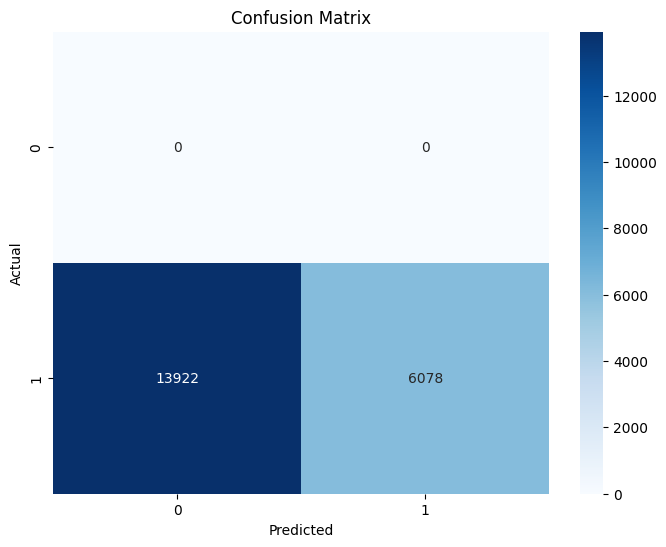

In [6]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
import faiss

# Compute R@1, R@5, R@10, R@20
RECALL_VALUES = [1, 5, 10, 20]

def test(eval_ds, model, num_preds_to_save=0):
    """Compute descriptors of the given dataset and compute the recalls."""
    
    model = model.eval()
    with torch.no_grad():
        print("Extracting database descriptors for evaluation/testing")
        database_subset_ds = Subset(eval_ds, list(range(eval_ds.database_num)))
        database_dataloader = DataLoader(dataset=database_subset_ds, batch_size=32, pin_memory=True)
        all_descriptors = np.empty((len(eval_ds), 2048), dtype="float32")
        for images, indices in tqdm(database_dataloader, ncols=100):
            descriptors = model(images.to("cuda"))
            descriptors = descriptors.cpu().numpy()
            all_descriptors[indices.numpy(), :] = descriptors
        
        print("Extracting queries descriptors for evaluation/testing using batch size 1")
        queries_infer_batch_size = 1
        queries_subset_ds = Subset(eval_ds, list(range(eval_ds.database_num, eval_ds.database_num+eval_ds.queries_num)))
        queries_dataloader = DataLoader(dataset=queries_subset_ds, batch_size=queries_infer_batch_size, pin_memory=True)
        for images, indices in tqdm(queries_dataloader, ncols=100):
            descriptors = model(images.to("cuda"))
            descriptors = descriptors.cpu().numpy()
            all_descriptors[indices.numpy(), :] = descriptors
    
    queries_descriptors = all_descriptors[eval_ds.database_num:]
    database_descriptors = all_descriptors[:eval_ds.database_num]
    
    # Use a kNN to find predictions
    faiss_index = faiss.IndexFlatL2(2048)
    faiss_index.add(database_descriptors)
    del database_descriptors, all_descriptors
    
    print("Calculating recalls")
    _, predictions = faiss_index.search(queries_descriptors, max(RECALL_VALUES))
    
    # Compute recall
    positives_per_query = eval_ds.get_positives()
    recalls = np.zeros(len(RECALL_VALUES))
    true_labels = []
    pred_labels = []
    
    for query_index, preds in enumerate(predictions):
        
        # Binary labels for each prediction
        binary_labels = np.in1d(preds, positives_per_query[query_index]).astype(int)
        pred_labels.extend(binary_labels)
        
        # Extend true labels with the correct number of positives (1) and the rest as negatives (0)
        true_labels.extend([1] * len(binary_labels))
        
        for i, n in enumerate(RECALL_VALUES):
            if np.any(binary_labels[:n]):
                recalls[i:] += 1
                break
    
    # Divide by queries_num and multiply by 100, so the recalls are in percentages
    recalls = recalls / eval_ds.queries_num * 100
    recalls_str = ", ".join([f"R@{val}: {rec:.1f}" for val, rec in zip(RECALL_VALUES, recalls)])
    print(recalls_str)
    # Compute additional metrics
    precision = precision_score(true_labels, pred_labels)
    print(f"Precision: {precision:.2f}")
    accuracy = accuracy_score(true_labels, pred_labels)
    print(f"Accuracy: {accuracy:.2f}")
    f1 = f1_score(true_labels, pred_labels)
    print(f"F1 Score: {f1:.2f}")
    conf_matrix = confusion_matrix(true_labels, pred_labels)
    #auc = roc_auc_score(true_labels, pred_labels)
    #print(f"AUC: {auc:.2f}")
    
    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()
    

    
    
    
    
    
    # Save visualizations of predictions
    #if num_preds_to_save != 0:
        #visualizations.save_preds(predictions[:, :num_preds_to_save], eval_ds, "Visualizations_folder", False)
    
    return recalls, recalls_str

# Assuming you have the Dataset and DataLoader set up as in your original code
# And assuming `model` is your trained model
test_ds = TestDataset("small/test", queries_folder="queries_v1")
recalls, recalls_str = test(test_ds, model, 3)



Extracting database descriptors for evaluation/testing


100%|█████████████████████████████████████████████████████████████| 850/850 [09:47<00:00,  1.45it/s]


Extracting queries descriptors for evaluation/testing using batch size 1


100%|███████████████████████████████████████████████████████████| 1000/1000 [00:38<00:00, 26.30it/s]


Calculating recalls


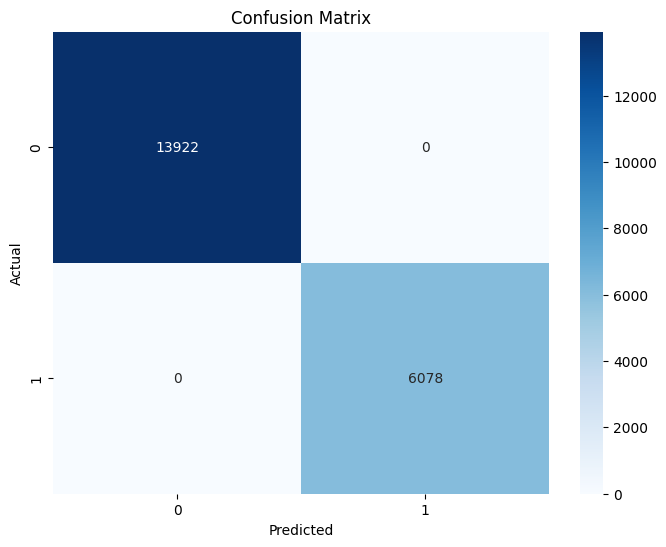

Precision: 1.00
Accuracy: 1.00
F1 Score: 1.00
AUC: 1.00


Saving preds in Visualizations_folder: 100%|█| 1000/1000 [04:33<00:00,  3.66it/s

R@1: 77.0, R@5: 84.0, R@10: 87.3, R@20: 89.2


In [7]:
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
import faiss

# Compute R@1, R@5, R@10, R@20
RECALL_VALUES = [1, 5, 10, 20]

def test(eval_ds, model, num_preds_to_save=0):
    """Compute descriptors of the given dataset and compute the recalls."""
    
    model = model.eval()
    with torch.no_grad():
        print("Extracting database descriptors for evaluation/testing")
        database_subset_ds = Subset(eval_ds, list(range(eval_ds.database_num)))
        database_dataloader = DataLoader(dataset=database_subset_ds, batch_size=32, pin_memory=True)
        all_descriptors = np.empty((len(eval_ds), 2048), dtype="float32")
        for images, indices in tqdm(database_dataloader, ncols=100):
            descriptors = model(images.to("cuda"))
            descriptors = descriptors.cpu().numpy()
            all_descriptors[indices.numpy(), :] = descriptors
        
        print("Extracting queries descriptors for evaluation/testing using batch size 1")
        queries_infer_batch_size = 1
        queries_subset_ds = Subset(eval_ds, list(range(eval_ds.database_num, eval_ds.database_num+eval_ds.queries_num)))
        queries_dataloader = DataLoader(dataset=queries_subset_ds, batch_size=queries_infer_batch_size, pin_memory=True)
        for images, indices in tqdm(queries_dataloader, ncols=100):
            descriptors = model(images.to("cuda"))
            descriptors = descriptors.cpu().numpy()
            all_descriptors[indices.numpy(), :] = descriptors
    
    queries_descriptors = all_descriptors[eval_ds.database_num:]
    database_descriptors = all_descriptors[:eval_ds.database_num]
    
    # Use a kNN to find predictions
    faiss_index = faiss.IndexFlatL2(2048)
    faiss_index.add(database_descriptors)
    del database_descriptors, all_descriptors
    
    print("Calculating recalls")
    _, predictions = faiss_index.search(queries_descriptors, max(RECALL_VALUES))
    
    # Compute recall
    positives_per_query = eval_ds.get_positives()
    recalls = np.zeros(len(RECALL_VALUES))
    true_labels = []
    pred_labels = []
    
    for query_index, preds in enumerate(predictions):
        true_positive_set = set(positives_per_query[query_index])
        
        # Binary labels for each prediction
        binary_labels = np.in1d(preds, positives_per_query[query_index]).astype(int)
        pred_labels.extend(binary_labels)
        
        # Extend true labels with positives (1) and negatives (0) corresponding to the predictions
        true_labels.extend([1 if idx in true_positive_set else 0 for idx in preds])
        
        for i, n in enumerate(RECALL_VALUES):
            if np.any(binary_labels[:n]):
                recalls[i:] += 1
                break
    
    # Divide by queries_num and multiply by 100, so the recalls are in percentages
    recalls = recalls / eval_ds.queries_num * 100
    recalls_str = ", ".join([f"R@{val}: {rec:.1f}" for val, rec in zip(RECALL_VALUES, recalls)])
    
    # Compute additional metrics
    precision = precision_score(true_labels, pred_labels, zero_division=0)
    accuracy = accuracy_score(true_labels, pred_labels)
    f1 = f1_score(true_labels, pred_labels)
    conf_matrix = confusion_matrix(true_labels, pred_labels)
    try:
        auc = roc_auc_score(true_labels, pred_labels)
    except ValueError:
        auc = float('nan')  # Handle cases where AUC can't be computed
    
    # Plot confusion matrix
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()
    
    print(f"Precision: {precision:.2f}")
    print(f"Accuracy: {accuracy:.2f}")
    print(f"F1 Score: {f1:.2f}")
    print(f"AUC: {auc:.2f}")
    
    # Save visualizations of predictions
    if num_preds_to_save != 0:
        visualizations.save_preds(predictions[:, :num_preds_to_save], eval_ds, "Visualizations_folder", False)
    
    return recalls, recalls_str

# Assuming you have the Dataset and DataLoader set up as in your original code
# And assuming `model` is your trained model
test_ds = TestDataset("small/test", queries_folder="queries_v1")
recalls, recalls_str = test(test_ds, model, 3)
print(recalls_str)


Extracting database descriptors for evaluation/testing


100%|█████████████████████████████████████████████████████████████| 850/850 [09:27<00:00,  1.50it/s]


Extracting queries descriptors for evaluation/testing using batch size 1


100%|███████████████████████████████████████████████████████████| 1000/1000 [00:36<00:00, 27.45it/s]


Calculating recalls


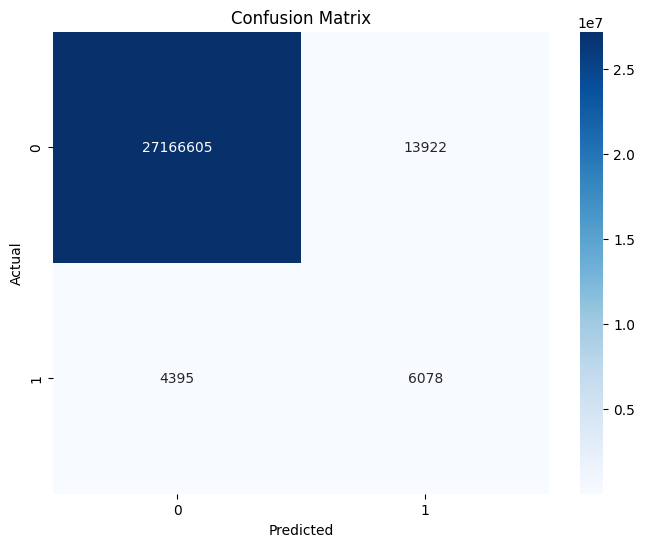

Precision: 0.30
Accuracy: 1.00
F1 Score: 0.40
AUC: nan


Saving preds in Visualizations_folder:  39%|▍| 390/1000 [01:37<02:33,  3.98it/s]


KeyboardInterrupt: 

In [4]:
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
import faiss
import matplotlib.pyplot as plt
import seaborn as sns

# Compute R@1, R@5, R@10, R@20
RECALL_VALUES = [1, 5, 10, 20]

def test(eval_ds, model, num_preds_to_save=0):
    """Compute descriptors of the given dataset and compute the recalls."""
    
    model = model.eval()
    with torch.no_grad():
        print("Extracting database descriptors for evaluation/testing")
        database_subset_ds = Subset(eval_ds, list(range(eval_ds.database_num)))
        database_dataloader = DataLoader(dataset=database_subset_ds, batch_size=32, pin_memory=True)
        all_descriptors = np.empty((len(eval_ds), 2048), dtype="float32")
        for images, indices in tqdm(database_dataloader, ncols=100):
            descriptors = model(images.to("cuda"))
            descriptors = descriptors.cpu().numpy()
            all_descriptors[indices.numpy(), :] = descriptors
        
        print("Extracting queries descriptors for evaluation/testing using batch size 1")
        queries_infer_batch_size = 1
        queries_subset_ds = Subset(eval_ds, list(range(eval_ds.database_num, eval_ds.database_num+eval_ds.queries_num)))
        queries_dataloader = DataLoader(dataset=queries_subset_ds, batch_size=queries_infer_batch_size, pin_memory=True)
        for images, indices in tqdm(queries_dataloader, ncols=100):
            descriptors = model(images.to("cuda"))
            descriptors = descriptors.cpu().numpy()
            all_descriptors[indices.numpy(), :] = descriptors
    
    queries_descriptors = all_descriptors[eval_ds.database_num:]
    database_descriptors = all_descriptors[:eval_ds.database_num]
    
    # Use a kNN to find predictions
    faiss_index = faiss.IndexFlatL2(2048)
    faiss_index.add(database_descriptors)
    del database_descriptors, all_descriptors
    
    print("Calculating recalls")
    _, predictions = faiss_index.search(queries_descriptors, max(RECALL_VALUES))
    
    #### For each query, check if the predictions are correct
    positives_per_query = eval_ds.get_positives()
    recalls = np.zeros(len(RECALL_VALUES))
    
    TP, TN, FP, FN = 0, 0, 0, 0
    
    for query_index, preds in enumerate(predictions):
        positives = set(positives_per_query[query_index])
        retrieved_set = set(preds)
        
        # True Positives: correct predictions
        tp = len(retrieved_set & positives)
        TP += tp
        
        # False Positives: retrieved but not relevant
        fp = len(retrieved_set - positives)
        FP += fp
        
        # False Negatives: not retrieved but relevant
        fn = len(positives - retrieved_set)
        FN += fn
        
        # True Negatives: not retrieved and not relevant
        tn = eval_ds.database_num - tp - fp - fn
        TN += tn
        
        for i, n in enumerate(RECALL_VALUES):
            if np.any(np.in1d(preds[:n], positives_per_query[query_index])):
                recalls[i:] += 1
                break
    
    # Divide by queries_num and multiply by 100, so the recalls are in percentages
    recalls = recalls / eval_ds.queries_num * 100
    recalls_str = ", ".join([f"R@{val}: {rec:.1f}" for val, rec in zip(RECALL_VALUES, recalls)])
    
    # Compute additional metrics
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    accuracy = (TP + TN) / (TP + TN + FP + FN)
    f1 = (2 * TP) / (2 * TP + FP + FN) if (2 * TP + FP + FN) > 0 else 0
    auc = float('nan')  # AUC isn't meaningful in this context without scikit-learn's roc_auc_score
    
    # Plot confusion matrix
    conf_matrix = np.array([[TN, FP], [FN, TP]])
    plt.figure(figsize=(8, 6))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()
    
    print(f"Precision: {precision:.2f}")
    print(f"Accuracy: {accuracy:.2f}")
    print(f"F1 Score: {f1:.2f}")
    print(f"AUC: {auc:.2f}")  # Printing NaN for consistency
    
    # Save visualizations of predictions
    #if num_preds_to_save != 0:
    #    visualizations.save_preds(predictions[:, :num_preds_to_save], eval_ds, "Visualizations_folder", False)
    
    return recalls, recalls_str

# Assuming you have the Dataset and DataLoader set up as in your original code
# And assuming `model` is your trained model
test_ds = TestDataset("small/test", queries_folder="queries_v1")
recalls, recalls_str = test(test_ds, model, 3)
print(recalls_str)


In [5]:
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
import faiss

# Compute R@1, R@5, R@10, R@20
RECALL_VALUES = [1, 5, 10, 20]

def calculate_map(predictions, positives_per_query):
    average_precisions = []
    for query_index, preds in enumerate(predictions):
        relevant = set(positives_per_query[query_index])
        retrieved = preds
        num_relevant = len(relevant)
        
        if num_relevant == 0:
            continue
        
        precision_at_i = []
        num_hits = 0
        for i, pred in enumerate(retrieved):
            if pred in relevant:
                num_hits += 1
                precision_at_i.append(num_hits / (i + 1))
        
        if num_hits > 0:
            average_precisions.append(np.sum(precision_at_i) / num_hits)
        else:
            average_precisions.append(0.0)
    
    return np.mean(average_precisions)

def calculate_p_at_k(predictions, positives_per_query, k):
    precision_at_k = []
    for query_index, preds in enumerate(predictions):
        relevant = set(positives_per_query[query_index])
        retrieved = preds[:k]
        num_relevant = len(relevant)
        
        if num_relevant == 0:
            continue
        
        num_hits = len([pred for pred in retrieved if pred in relevant])
        precision_at_k.append(num_hits / k)
    
    return np.mean(precision_at_k)

def test(eval_ds, model, num_preds_to_save=0):
    model = model.eval()
    with torch.no_grad():
        print("Extracting database descriptors for evaluation/testing")
        database_subset_ds = Subset(eval_ds, list(range(eval_ds.database_num)))
        database_dataloader = DataLoader(dataset=database_subset_ds, batch_size=32, pin_memory=True)
        all_descriptors = np.empty((len(eval_ds), 2048), dtype="float32")
        for images, indices in tqdm(database_dataloader, ncols=100):
            descriptors = model(images.to("cuda"))
            descriptors = descriptors.cpu().numpy()
            all_descriptors[indices.numpy(), :] = descriptors
        
        print("Extracting queries descriptors for evaluation/testing using batch size 1")
        queries_infer_batch_size = 1
        queries_subset_ds = Subset(eval_ds, list(range(eval_ds.database_num, eval_ds.database_num+eval_ds.queries_num)))
        queries_dataloader = DataLoader(dataset=queries_subset_ds, batch_size=queries_infer_batch_size, pin_memory=True)
        for images, indices in tqdm(queries_dataloader, ncols=100):
            descriptors = model(images.to("cuda"))
            descriptors = descriptors.cpu().numpy()
            all_descriptors[indices.numpy(), :] = descriptors
    
    queries_descriptors = all_descriptors[eval_ds.database_num:]
    database_descriptors = all_descriptors[:eval_ds.database_num]
    
    # Use a kNN to find predictions
    faiss_index = faiss.IndexFlatL2(2048)
    faiss_index.add(database_descriptors)
    del database_descriptors, all_descriptors
    
    print("Calculating recalls and precisions")
    _, predictions = faiss_index.search(queries_descriptors, max(RECALL_VALUES))
    
    # Compute recall
    positives_per_query = eval_ds.get_positives()
    recalls = np.zeros(len(RECALL_VALUES))
    for query_index, preds in enumerate(predictions):
        for i, n in enumerate(RECALL_VALUES):
            if np.any(np.in1d(preds[:n], positives_per_query[query_index])):
                recalls[i:] += 1
                break
    
    recalls = recalls / eval_ds.queries_num * 100
    recalls_str = ", ".join([f"R@{val}: {rec:.1f}" for val, rec in zip(RECALL_VALUES, recalls)])
    
    # Compute precision at K
    precision_at_1 = calculate_p_at_k(predictions, positives_per_query, 1)
    precision_at_5 = calculate_p_at_k(predictions, positives_per_query, 5)
    precision_at_10 = calculate_p_at_k(predictions, positives_per_query, 10)
    precision_at_20 = calculate_p_at_k(predictions, positives_per_query, 20)
    
    # Compute mean average precision
    map_score = calculate_map(predictions, positives_per_query)
    
    precisions_str = f"P@1: {precision_at_1:.2f}, P@5: {precision_at_5:.2f}, P@10: {precision_at_10:.2f}, P@20: {precision_at_20:.2f}"
    map_str = f"mAP: {map_score:.2f}"
    
    print(recalls_str)
    print(precisions_str)
    print(map_str)
    
    return recalls, precisions_str, map_str

# Assuming you have the Dataset and DataLoader set up as in your original code
# And assuming `model` is your trained model
test_ds = TestDataset("small/test", queries_folder="queries_v1")
recalls, precisions_str, map_str = test(test_ds, model, 3)
print(recalls_str)
print(precisions_str)
print(map_str)


Extracting database descriptors for evaluation/testing


100%|█████████████████████████████████████████████████████████████| 850/850 [30:20<00:00,  2.14s/it]


Extracting queries descriptors for evaluation/testing using batch size 1


100%|███████████████████████████████████████████████████████████| 1000/1000 [00:34<00:00, 29.07it/s]


Calculating recalls and precisions
R@1: 77.0, R@5: 84.0, R@10: 87.3, R@20: 89.2
P@1: 0.80, P@5: 0.61, P@10: 0.47, P@20: 0.31
mAP: 0.73


NameError: name 'recalls_str' is not defined

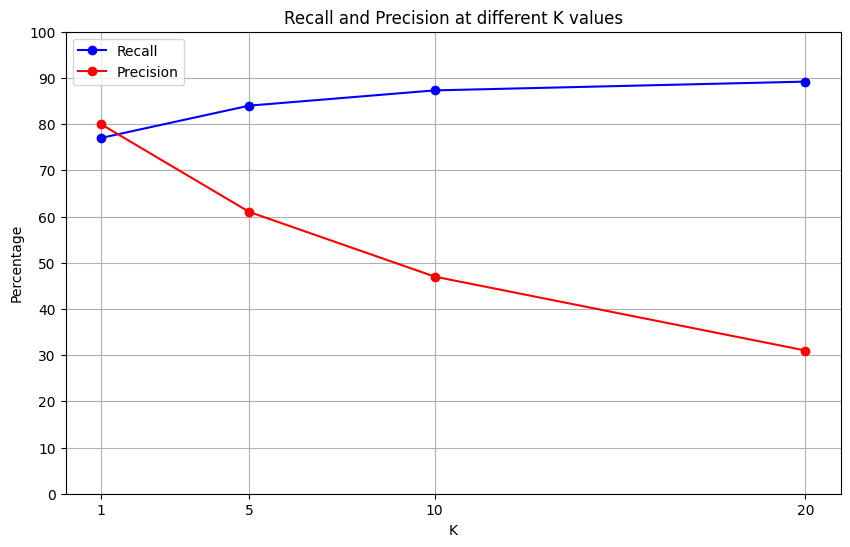

In [7]:
import matplotlib.pyplot as plt

# Sample data
recall_values = [77.0, 84.0, 87.3, 89.2]
precision_values = [0.80, 0.61, 0.47, 0.31]
precision_values_percent = [p * 100 for p in precision_values]  # Convert to percentage
k_values = [1, 5, 10, 20]

# Plotting
plt.figure(figsize=(10, 6))

# Plot recall
plt.plot(k_values, recall_values, marker='o', linestyle='-', color='b', label='Recall')

# Plot precision
plt.plot(k_values, precision_values_percent, marker='o', linestyle='-', color='r', label='Precision')

# Adding titles and labels
plt.title('Recall and Precision at different K values')
plt.xlabel('K')
plt.ylabel('Percentage')
plt.xticks(k_values)  # Ensuring only K values are used on the x-axis
plt.yticks(range(0, 101, 10))  # Set y-axis from 0 to 100

# Adding grid
plt.grid(True)

# Adding legend
plt.legend()

# Show plot
plt.show()


In [8]:
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
import faiss

# Compute R@1, R@5, R@10, R@20
RECALL_VALUES = [1, 5, 10, 20]

def calculate_ndcg(predictions, positives_per_query, k):
    ndcg_scores = []
    for query_index, preds in enumerate(predictions):
        relevant = set(positives_per_query[query_index])
        retrieved = preds[:k]
        num_relevant = len(relevant)
        
        if num_relevant == 0:
            continue
        
        dcg = 0.0
        idcg = 0.0
        sorted_relevance = sorted([1 if pred in relevant else 0 for pred in retrieved], reverse=True)
        
        for i, pred in enumerate(retrieved):
            if pred in relevant:
                dcg += 1 / np.log2(i + 2)
        
        for i, rel in enumerate(sorted_relevance):
            if rel == 1:
                idcg += 1 / np.log2(i + 2)
        
        ndcg_scores.append(dcg / idcg if idcg > 0 else 0.0)
    
    return np.mean(ndcg_scores)

def calculate_f1_at_k(predictions, positives_per_query, k):
    f1_scores = []
    for query_index, preds in enumerate(predictions):
        relevant = set(positives_per_query[query_index])
        retrieved = preds[:k]
        num_relevant = len(relevant)
        
        if num_relevant == 0:
            continue
        
        num_hits = len([pred for pred in retrieved if pred in relevant])
        precision_at_k = num_hits / k
        recall_at_k = num_hits / num_relevant
        
        if precision_at_k + recall_at_k == 0:
            f1_scores.append(0.0)
        else:
            f1_scores.append(2 * (precision_at_k * recall_at_k) / (precision_at_k + recall_at_k))
    
    return np.mean(f1_scores)

def test(eval_ds, model, num_preds_to_save=0):
    model = model.eval()
    with torch.no_grad():
        print("Extracting database descriptors for evaluation/testing")
        database_subset_ds = Subset(eval_ds, list(range(eval_ds.database_num)))
        database_dataloader = DataLoader(dataset=database_subset_ds, batch_size=32, pin_memory=True)
        all_descriptors = np.empty((len(eval_ds), 2048), dtype="float32")
        for images, indices in tqdm(database_dataloader, ncols=100):
            descriptors = model(images.to("cuda"))
            descriptors = descriptors.cpu().numpy()
            all_descriptors[indices.numpy(), :] = descriptors
        
        print("Extracting queries descriptors for evaluation/testing using batch size 1")
        queries_infer_batch_size = 1
        queries_subset_ds = Subset(eval_ds, list(range(eval_ds.database_num, eval_ds.database_num+eval_ds.queries_num)))
        queries_dataloader = DataLoader(dataset=queries_subset_ds, batch_size=queries_infer_batch_size, pin_memory=True)
        for images, indices in tqdm(queries_dataloader, ncols=100):
            descriptors = model(images.to("cuda"))
            descriptors = descriptors.cpu().numpy()
            all_descriptors[indices.numpy(), :] = descriptors
    
    queries_descriptors = all_descriptors[eval_ds.database_num:]
    database_descriptors = all_descriptors[:eval_ds.database_num]
    
    # Use a kNN to find predictions
    faiss_index = faiss.IndexFlatL2(2048)
    faiss_index.add(database_descriptors)
    del database_descriptors, all_descriptors
    
    print("Calculating recalls and precisions")
    _, predictions = faiss_index.search(queries_descriptors, max(RECALL_VALUES))
    
    # Compute recall
    positives_per_query = eval_ds.get_positives()
    recalls = np.zeros(len(RECALL_VALUES))
    for query_index, preds in enumerate(predictions):
        for i, n in enumerate(RECALL_VALUES):
            if np.any(np.in1d(preds[:n], positives_per_query[query_index])):
                recalls[i:] += 1
                break
    
    recalls = recalls / eval_ds.queries_num * 100
    recalls_str = ", ".join([f"R@{val}: {rec:.1f}" for val, rec in zip(RECALL_VALUES, recalls)])
    
    # Compute precision at K
    precision_at_1 = calculate_p_at_k(predictions, positives_per_query, 1)
    precision_at_5 = calculate_p_at_k(predictions, positives_per_query, 5)
    precision_at_10 = calculate_p_at_k(predictions, positives_per_query, 10)
    precision_at_20 = calculate_p_at_k(predictions, positives_per_query, 20)
    
    # Compute mean average precision
    map_score = calculate_map(predictions, positives_per_query)
    
    # Compute NDCG
    ndcg_at_1 = calculate_ndcg(predictions, positives_per_query, 1)
    ndcg_at_5 = calculate_ndcg(predictions, positives_per_query, 5)
    ndcg_at_10 = calculate_ndcg(predictions, positives_per_query, 10)
    ndcg_at_20 = calculate_ndcg(predictions, positives_per_query, 20)
    
    # Compute F1 at K
    f1_at_1 = calculate_f1_at_k(predictions, positives_per_query, 1)
    f1_at_5 = calculate_f1_at_k(predictions, positives_per_query, 5)
    f1_at_10 = calculate_f1_at_k(predictions, positives_per_query, 10)
    f1_at_20 = calculate_f1_at_k(predictions, positives_per_query, 20)
    
    precisions_str = f"P@1: {precision_at_1:.2f}%, P@5: {precision_at_5:.2f}%, P@10: {precision_at_10:.2f}%, P@20: {precision_at_20:.2f}%"
    ndcg_str = f"NDCG@1: {ndcg_at_1:.2f}, NDCG@5: {ndcg_at_5:.2f}, NDCG@10: {ndcg_at_10:.2f}, NDCG@20: {ndcg_at_20:.2f}"
    f1_str = f"F1@1: {f1_at_1:.2f}, F1@5: {f1_at_5:.2f}, F1@10: {f1_at_10:.2f}, F1@20: {f1_at_20:.2f}"
    map_str = f"mAP: {map_score:.2f}%"
    
    print(recalls_str)
    print(precisions_str)
    print(ndcg_str)
    print(f1_str)
    print(map_str)
    
    return recalls, precisions_str, ndcg_str, f1_str, map_str

# Assuming you have the Dataset and DataLoader set up as in your original code
# And assuming `model` is your trained model
test_ds = TestDataset("small/test", queries_folder="queries_v1")
recalls, precisions_str, ndcg_str, f1_str, map_str = test(test_ds, model, 3)
print(recalls_str)
print(precisions_str)
print(ndcg_str)
print(f1_str)
print(map_str)


Extracting database descriptors for evaluation/testing


  5%|███▏                                                          | 43/850 [01:06<20:56,  1.56s/it]


KeyboardInterrupt: 

In [ ]:
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
import faiss
from sklearn.metrics import precision_recall_curve, roc_curve, auc

# Compute R@1, R@5, R@10, R@20
RECALL_VALUES = [1, 5, 10, 20]

def calculate_map(predictions, positives_per_query):
    average_precisions = []
    for query_index, preds in enumerate(predictions):
        relevant = set(positives_per_query[query_index])
        retrieved = preds
        num_relevant = len(relevant)
        
        if num_relevant == 0:
            continue
        
        precision_at_i = []
        num_hits = 0
        for i, pred in enumerate(retrieved):
            if pred in relevant:
                num_hits += 1
                precision_at_i.append(num_hits / (i + 1))
        
        if num_hits > 0:
            average_precisions.append(np.sum(precision_at_i) / num_hits)
        else:
            average_precisions.append(0.0)
    
    return np.mean(average_precisions)

def calculate_p_at_k(predictions, positives_per_query, k):
    precision_at_k = []
    for query_index, preds in enumerate(predictions):
        relevant = set(positives_per_query[query_index])
        retrieved = preds[:k]
        num_relevant = len(relevant)
        
        if num_relevant == 0:
            continue
        
        num_hits = len([pred for pred in retrieved if pred in relevant])
        precision_at_k.append(num_hits / k * 100)  # Convert to percentage
    
    return np.mean(precision_at_k)

def calculate_ndcg(predictions, positives_per_query, k):
    ndcg_scores = []
    for query_index, preds in enumerate(predictions):
        relevant = set(positives_per_query[query_index])
        retrieved = preds[:k]
        num_relevant = len(relevant)
        
        if num_relevant == 0:
            continue
        
        dcg = 0.0
        idcg = 0.0
        sorted_relevance = sorted([1 if pred in relevant else 0 for pred in retrieved], reverse=True)
        
        for i, pred in enumerate(retrieved):
            if pred in relevant:
                dcg += 1 / np.log2(i + 2)
        
        for i, rel in enumerate(sorted_relevance):
            if rel == 1:
                idcg += 1 / np.log2(i + 2)
        
        ndcg_scores.append(dcg / idcg if idcg > 0 else 0.0)
    
    return np.mean(ndcg_scores)

def calculate_f1_at_k(predictions, positives_per_query, k):
    f1_scores = []
    for query_index, preds in enumerate(predictions):
        relevant = set(positives_per_query[query_index])
        retrieved = preds[:k]
        num_relevant = len(relevant)
        
        if num_relevant == 0:
            continue
        
        num_hits = len([pred for pred in retrieved if pred in relevant])
        precision_at_k = num_hits / k
        recall_at_k = num_hits / num_relevant
        
        if precision_at_k + recall_at_k == 0:
            f1_scores.append(0.0)
        else:
            f1_scores.append(2 * (precision_at_k * recall_at_k) / (precision_at_k + recall_at_k))
    
    return np.mean(f1_scores)

def test(eval_ds, model, num_preds_to_save=0):
    model = model.eval()
    with torch.no_grad():
        print("Extracting database descriptors for evaluation/testing")
        database_subset_ds = Subset(eval_ds, list(range(eval_ds.database_num)))
        database_dataloader = DataLoader(dataset=database_subset_ds, batch_size=32, pin_memory=True)
        all_descriptors = np.empty((len(eval_ds), 2048), dtype="float32")
        for images, indices in tqdm(database_dataloader, ncols=100):
            descriptors = model(images.to("cuda"))
            descriptors = descriptors.cpu().numpy()
            all_descriptors[indices.numpy(), :] = descriptors
        
        print("Extracting queries descriptors for evaluation/testing using batch size 1")
        queries_infer_batch_size = 1
        queries_subset_ds = Subset(eval_ds, list(range(eval_ds.database_num, eval_ds.database_num+eval_ds.queries_num)))
        queries_dataloader = DataLoader(dataset=queries_subset_ds, batch_size=queries_infer_batch_size, pin_memory=True)
        for images, indices in tqdm(queries_dataloader, ncols=100):
            descriptors = model(images.to("cuda"))
            descriptors = descriptors.cpu().numpy()
            all_descriptors[indices.numpy(), :] = descriptors
    
    queries_descriptors = all_descriptors[eval_ds.database_num:]
    database_descriptors = all_descriptors[:eval_ds.database_num]
    
    # Use a kNN to find predictions
    faiss_index = faiss.IndexFlatL2(2048)
    faiss_index.add(database_descriptors)
    del database_descriptors, all_descriptors
    
    print("Calculating recalls and precisions")
    _, predictions = faiss_index.search(queries_descriptors, max(RECALL_VALUES))
    
    # Compute recall
    positives_per_query = eval_ds.get_positives()
    recalls = np.zeros(len(RECALL_VALUES))
    for query_index, preds in enumerate(predictions):
        for i, n in enumerate(RECALL_VALUES):
            if np.any(np.in1d(preds[:n], positives_per_query[query_index])):
                recalls[i:] += 1
                break
    
    recalls = recalls / eval_ds.queries_num * 100
    recalls_str = ", ".join([f"R@{val}: {rec:.1f}%" for val, rec in zip(RECALL_VALUES, recalls)])
    
    # Compute precision at K
    precision_at_1 = calculate_p_at_k(predictions, positives_per_query, 1)
    precision_at_5 = calculate_p_at_k(predictions, positives_per_query, 5)
    precision_at_10 = calculate_p_at_k(predictions, positives_per_query, 10)
    precision_at_20 = calculate_p_at_k(predictions, positives_per_query, 20)
    
    # Compute mean average precision
    map_score = calculate_map(predictions, positives_per_query)
    
    # Compute NDCG
    ndcg_at_1 = calculate_ndcg(predictions, positives_per_query, 1)
    ndcg_at_5 = calculate_ndcg(predictions, positives_per_query, 5)
    ndcg_at_10 = calculate_ndcg(predictions, positives_per_query, 10)
    ndcg_at_20 = calculate_ndcg(predictions, positives_per_query, 20)
    
    # Compute F1 at K
    f1_at_1 = calculate_f1_at_k(predictions, positives_per_query, 1)
    f1_at_5 = calculate_f1_at_k(predictions, positives_per_query, 5)
    f1_at_10 = calculate_f1_at_k(predictions, positives_per_query, 10)
    f1_at_20 = calculate_f1_at_k(predictions, positives_per_query, 20)
    
    # Compute precision-recall curve
    y_true = []
    y_scores = []
    for query_index, preds in enumerate(predictions):
        relevant = set(positives_per_query[query_index])
        y_true.extend([1 if i in relevant else 0 for i in range(len(preds))])
        y_scores.extend([1 / (i + 1) if preds[i] in relevant else 0 for i in range(len(preds))])
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    
    # Compute ROC curve and AUC
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    roc_auc = auc(fpr, tpr)
    
    precisions_str = f"P@1: {precision_at_1:.2f}%, P@5: {precision_at_5:.2f}%, P@10: {precision_at_10:.2f}%, P@20: {precision_at_20:.2f}%"
    ndcg_str = f"NDCG@1: {ndcg_at_1:.2f}, NDCG@5: {ndcg_at_5:.2f}, NDCG@10: {ndcg_at_10:.2f}, NDCG@20: {ndcg_at_20:.2f}"
    f1_str = f"F1@1: {f1_at_1:.2f}, F1@5: {f1_at_5:.2f}, F1@10: {f1_at_10:.2f}, F1@20: {f1_at_20:.2f}"
    map_str = f"mAP: {map_score:.2f}%"
    auc_str = f"AUC: {roc_auc:.2f}"
    
    print(recalls_str)
    print(precisions_str)
    print(ndcg_str)
    print(f1_str)
    print(map_str)
    print(auc_str)
    
    return recalls, precisions_str, ndcg_str, f1_str, map_str, auc_str, precision, recall, fpr, tpr

# Assuming you have the Dataset and DataLoader set up as in your original code
# And assuming `model` is your trained model
test_ds = TestDataset("small/test", queries_folder="queries_v1")
recalls, precisions_str, ndcg_str, f1_str, map_str, auc_str, precision, recall, fpr, tpr = test(test_ds, model, 3)

print(recalls_str)
print(precisions_str)
print(ndcg_str)
print(f1_str)
print(map_str)
print(auc_str)

# Plot Precision-Recall Curve
import matplotlib.pyplot as plt

plt.figure()
plt.plot(recall, precision, label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
plt.show()

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='best')
plt.show()



In [ ]:
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
import faiss
from sklearn.metrics import precision_recall_curve, roc_curve, auc

# Compute R@1, R@5, R@10, R@20
RECALL_VALUES = [1, 5, 10, 20]

def calculate_map(predictions, positives_per_query):
    average_precisions = []
    for query_index, preds in enumerate(predictions):
        relevant = set(positives_per_query[query_index])
        retrieved = preds
        num_relevant = len(relevant)
        
        if num_relevant == 0:
            continue
        
        precision_at_i = []
        num_hits = 0
        for i, pred in enumerate(retrieved):
            if pred in relevant:
                num_hits += 1
                precision_at_i.append(num_hits / (i + 1))
        
        if num_hits > 0:
            average_precisions.append(np.sum(precision_at_i) / num_hits)
        else:
            average_precisions.append(0.0)
    
    return np.mean(average_precisions)

def calculate_p_at_k(predictions, positives_per_query, k):
    precision_at_k = []
    for query_index, preds in enumerate(predictions):
        relevant = set(positives_per_query[query_index])
        retrieved = preds[:k]
        num_relevant = len(relevant)
        
        if num_relevant == 0:
            continue
        
        num_hits = len([pred for pred in retrieved if pred in relevant])
        precision_at_k.append(num_hits / k)
    
    return np.mean(precision_at_k)

def calculate_ndcg(predictions, positives_per_query, k):
    ndcg_scores = []
    for query_index, preds in enumerate(predictions):
        relevant = set(positives_per_query[query_index])
        retrieved = preds[:k]
        dcg = 0.0
        idcg = 0.0
        
        for i, pred in enumerate(retrieved):
            if pred in relevant:
                dcg += 1.0 / np.log2(i + 2)  # i+2 because log2(1) = 0
            
        for i in range(min(len(relevant), k)):
            idcg += 1.0 / np.log2(i + 2)
        
        ndcg_scores.append(dcg / idcg if idcg > 0 else 0.0)
    
    return np.mean(ndcg_scores)

def calculate_f1_at_k(precision, recall):
    return 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

def test(eval_ds, model, num_preds_to_save=0):
    model = model.eval()
    with torch.no_grad():
        print("Extracting database descriptors for evaluation/testing")
        database_subset_ds = Subset(eval_ds, list(range(eval_ds.database_num)))
        database_dataloader = DataLoader(dataset=database_subset_ds, batch_size=32, pin_memory=True)
        all_descriptors = np.empty((len(eval_ds), 2048), dtype="float32")
        for images, indices in tqdm(database_dataloader, ncols=100):
            descriptors = model(images.to("cuda"))
            descriptors = descriptors.cpu().numpy()
            all_descriptors[indices.numpy(), :] = descriptors
        
        print("Extracting queries descriptors for evaluation/testing using batch size 1")
        queries_infer_batch_size = 1
        queries_subset_ds = Subset(eval_ds, list(range(eval_ds.database_num, eval_ds.database_num + eval_ds.queries_num)))
        queries_dataloader = DataLoader(dataset=queries_subset_ds, batch_size=queries_infer_batch_size, pin_memory=True)
        for images, indices in tqdm(queries_dataloader, ncols=100):
            descriptors = model(images.to("cuda"))
            descriptors = descriptors.cpu().numpy()
            all_descriptors[indices.numpy(), :] = descriptors
    
    queries_descriptors = all_descriptors[eval_ds.database_num:]
    database_descriptors = all_descriptors[:eval_ds.database_num]
    
    # Use a kNN to find predictions
    faiss_index = faiss.IndexFlatL2(2048)
    faiss_index.add(database_descriptors)
    del database_descriptors, all_descriptors
    
    print("Calculating recalls and precisions")
    _, predictions = faiss_index.search(queries_descriptors, max(RECALL_VALUES))
    
    # Compute recall
    positives_per_query = eval_ds.get_positives()
    recalls = np.zeros(len(RECALL_VALUES))
    for query_index, preds in enumerate(predictions):
        for i, n in enumerate(RECALL_VALUES):
            if np.any(np.in1d(preds[:n], positives_per_query[query_index])):
                recalls[i:] += 1
                break
    
    recalls = recalls / eval_ds.queries_num * 100
    recalls_str = ", ".join([f"R@{val}: {rec:.1f}" for val, rec in zip(RECALL_VALUES, recalls)])
    
    # Compute precision at K
    precision_at_1 = calculate_p_at_k(predictions, positives_per_query, 1) * 100
    precision_at_5 = calculate_p_at_k(predictions, positives_per_query, 5) * 100
    precision_at_10 = calculate_p_at_k(predictions, positives_per_query, 10) * 100
    precision_at_20 = calculate_p_at_k(predictions, positives_per_query, 20) * 100
    
    # Compute mean average precision
    map_score = calculate_map(predictions, positives_per_query) * 100
    
    precisions_str = f"P@1: {precision_at_1:.2f}, P@5: {precision_at_5:.2f}, P@10: {precision_at_10:.2f}, P@20: {precision_at_20:.2f}"
    map_str = f"mAP: {map_score:.2f}"
    
    # Compute NDCG at K
    ndcg_at_1 = calculate_ndcg(predictions, positives_per_query, 1)
    ndcg_at_5 = calculate_ndcg(predictions, positives_per_query, 5)
    ndcg_at_10 = calculate_ndcg(predictions, positives_per_query, 10)
    ndcg_at_20 = calculate_ndcg(predictions, positives_per_query, 20)
    ndcg_str = f"NDCG@1: {ndcg_at_1:.2f}, NDCG@5: {ndcg_at_5:.2f}, NDCG@10: {ndcg_at_10:.2f}, NDCG@20: {ndcg_at_20:.2f}"
    
    # Compute F1@K
    f1_at_1 = calculate_f1_at_k(precision_at_1, recalls[0])
    f1_at_5 = calculate_f1_at_k(precision_at_5, recalls[1])
    f1_at_10 = calculate_f1_at_k(precision_at_10, recalls[2])
    f1_at_20 = calculate_f1_at_k(precision_at_20, recalls[3])
    f1_str = f"F1@1: {f1_at_1:.2f}, F1@5: {f1_at_5:.2f}, F1@10: {f1_at_10:.2f}, F1@20: {f1_at_20:.2f}"
    
    # Compute Precision-Recall and ROC Curve
    y_true = np.zeros((eval_ds.queries_num, eval_ds.database_num))
    for i, positives in enumerate(positives_per_query):
        y_true[i, positives] = 1
    
    y_scores = np.zeros((eval_ds.queries_num, eval_ds.database_num))
    for i, preds in enumerate(predictions):
        y_scores[i, preds] = 1 / (np.arange(len(preds)) + 1)
    
    precision, recall, _ = precision_recall_curve(y_true.ravel(), y_scores.ravel())
    fpr, tpr, _ = roc_curve(y_true.ravel(), y_scores.ravel())
    roc_auc = auc(fpr, tpr)
    auc_str = f"AUC: {roc_auc:.2f}"
    
    print(recalls_str)
    print(precisions_str)
    print(ndcg_str)
    print(f1_str)
    print(map_str)
    print(auc_str)
    
    return recalls, precisions_str, ndcg_str, f1_str, map_str, auc_str, precision, recall, fpr, tpr

# Assuming you have the Dataset and DataLoader set up as in your original code
# And assuming `model` is your trained model
test_ds = TestDataset("small/test", queries_folder="queries_v1")
recalls_str, precisions_str, ndcg_str


In [ ]:
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
import faiss
from sklearn.metrics import precision_recall_curve, roc_curve, auc
import matplotlib.pyplot as plt

# Compute R@1, R@5, R@10, R@20
RECALL_VALUES = [1, 5, 10, 20]

def calculate_map(predictions, positives_per_query):
    average_precisions = []
    for query_index, preds in enumerate(predictions):
        relevant = set(positives_per_query[query_index])
        retrieved = preds
        num_relevant = len(relevant)
        
        if num_relevant == 0:
            continue
        
        precision_at_i = []
        num_hits = 0
        for i, pred in enumerate(retrieved):
            if pred in relevant:
                num_hits += 1
                precision_at_i.append(num_hits / (i + 1))
        
        if num_hits > 0:
            average_precisions.append(np.sum(precision_at_i) / num_hits)
        else:
            average_precisions.append(0.0)
    
    return np.mean(average_precisions)

def calculate_p_at_k(predictions, positives_per_query, k):
    precision_at_k = []
    for query_index, preds in enumerate(predictions):
        relevant = set(positives_per_query[query_index])
        retrieved = preds[:k]
        num_relevant = len(relevant)
        
        if num_relevant == 0:
            continue
        
        num_hits = len([pred for pred in retrieved if pred in relevant])
        precision_at_k.append(num_hits / k)
    
    return np.mean(precision_at_k)

def calculate_ndcg(predictions, positives_per_query, k):
    ndcg_scores = []
    for query_index, preds in enumerate(predictions):
        relevant = set(positives_per_query[query_index])
        retrieved = preds[:k]
        dcg = 0.0
        idcg = 0.0
        
        for i, pred in enumerate(retrieved):
            if pred in relevant:
                dcg += 1.0 / np.log2(i + 2)  # i+2 because log2(1) = 0
            
        for i in range(min(len(relevant), k)):
            idcg += 1.0 / np.log2(i + 2)
        
        ndcg_scores.append(dcg / idcg if idcg > 0 else 0.0)
    
    return np.mean(ndcg_scores)

def calculate_f1_at_k(precision, recall):
    return 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

def test(eval_ds, model, num_preds_to_save=0):
    model = model.eval()
    with torch.no_grad():
        print("Extracting database descriptors for evaluation/testing")
        database_subset_ds = Subset(eval_ds, list(range(eval_ds.database_num)))
        database_dataloader = DataLoader(dataset=database_subset_ds, batch_size=32, pin_memory=True)
        all_descriptors = np.empty((len(eval_ds), 2048), dtype="float32")
        for images, indices in tqdm(database_dataloader, ncols=100):
            descriptors = model(images.to("cuda"))
            descriptors = descriptors.cpu().numpy()
            all_descriptors[indices.numpy(), :] = descriptors
        
        print("Extracting queries descriptors for evaluation/testing using batch size 1")
        queries_infer_batch_size = 1
        queries_subset_ds = Subset(eval_ds, list(range(eval_ds.database_num, eval_ds.database_num + eval_ds.queries_num)))
        queries_dataloader = DataLoader(dataset=queries_subset_ds, batch_size=queries_infer_batch_size, pin_memory=True)
        for images, indices in tqdm(queries_dataloader, ncols=100):
            descriptors = model(images.to("cuda"))
            descriptors = descriptors.cpu().numpy()
            all_descriptors[indices.numpy(), :] = descriptors
    
    queries_descriptors = all_descriptors[eval_ds.database_num:]
    database_descriptors = all_descriptors[:eval_ds.database_num]
    
    # Use a kNN to find predictions
    faiss_index = faiss.IndexFlatL2(2048)
    faiss_index.add(database_descriptors)
    del database_descriptors, all_descriptors
    
    print("Calculating recalls and precisions")
    _, predictions = faiss_index.search(queries_descriptors, max(RECALL_VALUES))
    
    # Compute recall
    positives_per_query = eval_ds.get_positives()
    recalls = np.zeros(len(RECALL_VALUES))
    for query_index, preds in enumerate(predictions):
        for i, n in enumerate(RECALL_VALUES):
            if np.any(np.in1d(preds[:n], positives_per_query[query_index])):
                recalls[i:] += 1
                break
    
    recalls = recalls / eval_ds.queries_num * 100
    recalls_str = ", ".join([f"R@{val}: {rec:.1f}" for val, rec in zip(RECALL_VALUES, recalls)])
    
    # Compute precision at K
    precision_at_1 = calculate_p_at_k(predictions, positives_per_query, 1) * 100
    precision_at_5 = calculate_p_at_k(predictions, positives_per_query, 5) * 100
    precision_at_10 = calculate_p_at_k(predictions, positives_per_query, 10) * 100
    precision_at_20 = calculate_p_at_k(predictions, positives_per_query, 20) * 100
    
    # Compute mean average precision
    map_score = calculate_map(predictions, positives_per_query) * 100
    
    precisions_str = f"P@1: {precision_at_1:.2f}, P@5: {precision_at_5:.2f}, P@10: {precision_at_10:.2f}, P@20: {precision_at_20:.2f}"
    map_str = f"mAP: {map_score:.2f}"
    
    # Compute NDCG at K
    ndcg_at_1 = calculate_ndcg(predictions, positives_per_query, 1)
    ndcg_at_5 = calculate_ndcg(predictions, positives_per_query, 5)
    ndcg_at_10 = calculate_ndcg(predictions, positives_per_query, 10)
    ndcg_at_20 = calculate_ndcg(predictions, positives_per_query, 20)
    ndcg_str = f"NDCG@1: {ndcg_at_1:.2f}, NDCG@5: {ndcg_at_5:.2f}, NDCG@10: {ndcg_at_10:.2f}, NDCG@20: {ndcg_at_20:.2f}"
    
    # Compute F1@K
    f1_at_1 = calculate_f1_at_k(precision_at_1, recalls[0])
    f1_at_5 = calculate_f1_at_k(precision_at_5, recalls[1])
    f1_at_10 = calculate_f1_at_k(precision_at_10, recalls[2])
    f1_at_20 = calculate_f1_at_k(precision_at_20, recalls[3])
    f1_str = f"F1@1: {f1_at_1:.2f}, F1@5: {f1_at_5:.2f}, F1@10: {f1_at_10:.2f}, F1@20: {f1_at_20:.2f}"
    
    # Compute Precision-Recall and ROC Curve
    y_true = np.zeros((eval_ds.queries_num, eval_ds.database_num))
    for i, positives in enumerate(positives_per_query):
        y_true[i, positives] = 1
    
    y_scores = np.zeros((eval_ds.queries_num, eval_ds.database_num))
    for i, preds in enumerate(predictions):
        y_scores[i, preds] = 1 / (np.arange(len(preds)) + 1)
    
    precision, recall, _ = precision_recall_curve(y_true.ravel(), y_scores.ravel())
    fpr, tpr, _ = roc_curve(y_true.ravel(), y_scores.ravel())
    roc_auc = auc(fpr, tpr)
    auc_str = f"AUC: {roc_auc:.2f}"
    
    print(recalls_str)
    print(precisions_str)
    print(ndcg_str)
    print(f1_str)
    print(map_str)
    print(auc_str)
    
    return recalls, precisions_str, ndcg_str, f1_str, map_str, auc_str, precision, recall, fpr, tpr

# Assuming you have the Dataset and DataLoader set up as in your original code
# And assuming `model` is your trained model
test_ds = TestDataset("small/test", queries_folder="queries_v1")
recalls, precisions_str, ndcg_str, f1_str, map_str, auc_str, precision, recall, fpr, tpr = test(test_ds, model, 3)

print(recalls_str)
print(precisions_str)
print(ndcg_str)
print(f1_str)
print(map_str)
print(auc_str)

# Plot Precision-Recall Curve
plt.figure()
plt.plot(recall, precision, label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
plt.show()

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='best')
plt.show()


# test dataset

## Resnet 50 dim 2048 

In [2]:
model = torch.hub.load("gmberton/cosplace", "get_trained_model", backbone="ResNet50", fc_output_dim=2048)
model.to("cuda")

Using cache found in C:\Users\chiga/.cache\torch\hub\gmberton_cosplace_main


Returning CosPlace model with backbone: ResNet50 with features dimension 2048


GeoLocalizationNet(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0):

In [14]:
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
import faiss
from sklearn.metrics import precision_recall_curve, roc_curve, auc
import matplotlib.pyplot as plt

# Compute R@1, R@5, R@10, R@20
RECALL_VALUES = [1, 5, 10, 20]

def calculate_map(predictions, positives_per_query):
    average_precisions = []
    for query_index, preds in enumerate(predictions):
        relevant = set(positives_per_query[query_index])
        retrieved = preds
        num_relevant = len(relevant)
        
        if num_relevant == 0:
            continue
        
        precision_at_i = []
        num_hits = 0
        for i, pred in enumerate(retrieved):
            if pred in relevant:
                num_hits += 1
                precision_at_i.append(num_hits / (i + 1))
        
        if num_hits > 0:
            average_precisions.append(np.sum(precision_at_i) / num_hits)
        else:
            average_precisions.append(0.0)
    
    return np.mean(average_precisions)

def calculate_p_at_k(predictions, positives_per_query, k):
    precision_at_k = []
    for query_index, preds in enumerate(predictions):
        relevant = set(positives_per_query[query_index])
        retrieved = preds[:k]
        num_relevant = len(relevant)
        
        if num_relevant == 0:
            continue
        
        num_hits = len([pred for pred in retrieved if pred in relevant])
        precision_at_k.append(num_hits / k)
    
    return np.mean(precision_at_k)

def calculate_ndcg(predictions, positives_per_query, k):
    ndcg_scores = []
    for query_index, preds in enumerate(predictions):
        relevant = set(positives_per_query[query_index])
        retrieved = preds[:k]
        dcg = 0.0
        idcg = 0.0
        
        for i, pred in enumerate(retrieved):
            if pred in relevant:
                dcg += 1.0 / np.log2(i + 2)  # i+2 because log2(1) = 0
            
        for i in range(min(len(relevant), k)):
            idcg += 1.0 / np.log2(i + 2)
        
        ndcg_scores.append(dcg / idcg if idcg > 0 else 0.0)
    
    return np.mean(ndcg_scores)

def calculate_f1_at_k(precision, recall):
    return 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

def test(eval_ds, model, num_preds_to_save=0):
    model = model.eval()
    with torch.no_grad():
        print("Extracting database descriptors for evaluation/testing")
        database_subset_ds = Subset(eval_ds, list(range(eval_ds.database_num)))
        database_dataloader = DataLoader(dataset=database_subset_ds, batch_size=32, pin_memory=True)
        all_descriptors = np.empty((len(eval_ds), 2048), dtype="float32")
        for images, indices in tqdm(database_dataloader, ncols=100):
            descriptors = model(images.to("cuda"))
            descriptors = descriptors.cpu().numpy()
            all_descriptors[indices.numpy(), :] = descriptors
        
        print("Extracting queries descriptors for evaluation/testing using batch size 1")
        queries_infer_batch_size = 1
        queries_subset_ds = Subset(eval_ds, list(range(eval_ds.database_num, eval_ds.database_num + eval_ds.queries_num)))
        queries_dataloader = DataLoader(dataset=queries_subset_ds, batch_size=queries_infer_batch_size, pin_memory=True)
        for images, indices in tqdm(queries_dataloader, ncols=100):
            descriptors = model(images.to("cuda"))
            descriptors = descriptors.cpu().numpy()
            all_descriptors[indices.numpy(), :] = descriptors
    
    queries_descriptors = all_descriptors[eval_ds.database_num:]
    database_descriptors = all_descriptors[:eval_ds.database_num]
    
    # Use a kNN to find predictions
    faiss_index = faiss.IndexFlatL2(2048)
    faiss_index.add(database_descriptors)
    del database_descriptors, all_descriptors
    
    print("Calculating recalls and precisions")
    _, predictions = faiss_index.search(queries_descriptors, max(RECALL_VALUES))
    
    # Compute recall
    positives_per_query = eval_ds.get_positives()
    recalls = np.zeros(len(RECALL_VALUES))
    for query_index, preds in enumerate(predictions):
        for i, n in enumerate(RECALL_VALUES):
            if np.any(np.in1d(preds[:n], positives_per_query[query_index])):
                recalls[i:] += 1
                break
    
    recalls = recalls / eval_ds.queries_num * 100
    recalls_str = ", ".join([f"R@{val}: {rec:.1f}" for val, rec in zip(RECALL_VALUES, recalls)])
    
    # Compute precision at K
    precision_at_1 = calculate_p_at_k(predictions, positives_per_query, 1) * 100
    precision_at_5 = calculate_p_at_k(predictions, positives_per_query, 5) * 100
    precision_at_10 = calculate_p_at_k(predictions, positives_per_query, 10) * 100
    precision_at_20 = calculate_p_at_k(predictions, positives_per_query, 20) * 100
    
    # Compute mean average precision
    map_score = calculate_map(predictions, positives_per_query) * 100
    
    precisions_str = f"P@1: {precision_at_1:.2f}, P@5: {precision_at_5:.2f}, P@10: {precision_at_10:.2f}, P@20: {precision_at_20:.2f}"
    map_str = f"mAP: {map_score:.2f}"
    
    # Compute NDCG at K
    ndcg_at_1 = calculate_ndcg(predictions, positives_per_query, 1)
    ndcg_at_5 = calculate_ndcg(predictions, positives_per_query, 5)
    ndcg_at_10 = calculate_ndcg(predictions, positives_per_query, 10)
    ndcg_at_20 = calculate_ndcg(predictions, positives_per_query, 20)
    ndcg_str = f"NDCG@1: {ndcg_at_1:.2f}, NDCG@5: {ndcg_at_5:.2f}, NDCG@10: {ndcg_at_10:.2f}, NDCG@20: {ndcg_at_20:.2f}"
    
    # Compute F1@K
    f1_at_1 = calculate_f1_at_k(precision_at_1, recalls[0])
    f1_at_5 = calculate_f1_at_k(precision_at_5, recalls[1])
    f1_at_10 = calculate_f1_at_k(precision_at_10, recalls[2])
    f1_at_20 = calculate_f1_at_k(precision_at_20, recalls[3])
    f1_str = f"F1@1: {f1_at_1:.2f}, F1@5: {f1_at_5:.2f}, F1@10: {f1_at_10:.2f}, F1@20: {f1_at_20:.2f}"
    
    # Compute Precision-Recall and ROC Curve
    y_true = np.zeros((eval_ds.queries_num, eval_ds.database_num))
    for i, positives in enumerate(positives_per_query):
        y_true[i, positives] = 1
    
    y_scores = np.zeros((eval_ds.queries_num, eval_ds.database_num))
    for i, preds in enumerate(predictions):
        y_scores[i, preds] = 1 / (np.arange(len(preds)) + 1)
    
    precision, recall, _ = precision_recall_curve(y_true.ravel(), y_scores.ravel())
    fpr, tpr, _ = roc_curve(y_true.ravel(), y_scores.ravel())
    roc_auc = auc(fpr, tpr)
    auc_str = f"AUC: {roc_auc:.2f}"
    
    print(recalls_str)
    print(precisions_str)
    print(ndcg_str)
    print(f1_str)
    print(map_str)
    print(auc_str)
    
    return recalls, recalls_str, precisions_str, ndcg_str, f1_str, map_str, auc_str, precision, recall, fpr, tpr, roc_auc

# Assuming you have the Dataset and DataLoader set up as in your original code
# And assuming `model` is your trained model
test_ds = TestDataset("small/test", queries_folder="queries_v1")
recalls, recalls_str, precisions_str, ndcg_str, f1_str, map_str, auc_str, precision, recall, fpr, tpr, roc_auc = test(test_ds, model, 3)

print(recalls_str)
print(precisions_str)
print(ndcg_str)
print(f1_str)
print(map_str)
print(auc_str)

# Plot Precision-Recall Curve
plt.figure()
plt.plot(recall, precision, label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
plt.show()

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='best')
plt.show()

Extracting database descriptors for evaluation/testing


  0%|                                                                       | 0/850 [00:07<?, ?it/s]


ValueError: shape mismatch: value array of shape (32,512) could not be broadcast to indexing result of shape (32,2048)

## Resnet 18 dim 512

In [3]:
model = torch.hub.load("gmberton/cosplace", "get_trained_model", backbone="ResNet18", fc_output_dim=512)
model.to("cuda")

Using cache found in C:\Users\chiga/.cache\torch\hub\gmberton_cosplace_main


Returning CosPlace model with backbone: ResNet18 with features dimension 512


Downloading: "https://github.com/gmberton/CosPlace/releases/download/v1.0/ResNet18_512_cosplace.pth" to C:\Users\chiga/.cache\torch\hub\checkpoints\ResNet18_512_cosplace.pth
100%|██████████| 43.7M/43.7M [00:35<00:00, 1.30MB/s]


GeoLocalizationNet(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running

Extracting database descriptors for evaluation/testing


100%|█████████████████████████████████████████████████████████████| 850/850 [07:13<00:00,  1.96it/s]


Extracting queries descriptors for evaluation/testing using batch size 1


100%|███████████████████████████████████████████████████████████| 1000/1000 [00:18<00:00, 52.75it/s]


Calculating recalls and precisions
R@1: 67.7, R@5: 77.8, R@10: 81.8, R@20: 85.0
P@1: 70.08, P@5: 51.53, P@10: 39.53, P@20: 26.89
NDCG@1: 0.68, NDCG@5: 0.57, NDCG@10: 0.53, NDCG@20: 0.53
F1@1: 68.87, F1@5: 62.00, F1@10: 53.31, F1@20: 40.85
mAP: 63.37
AUC: 0.75
R@1: 67.7, R@5: 77.8, R@10: 81.8, R@20: 85.0
P@1: 70.08, P@5: 51.53, P@10: 39.53, P@20: 26.89
NDCG@1: 0.68, NDCG@5: 0.57, NDCG@10: 0.53, NDCG@20: 0.53
F1@1: 68.87, F1@5: 62.00, F1@10: 53.31, F1@20: 40.85
mAP: 63.37
AUC: 0.75


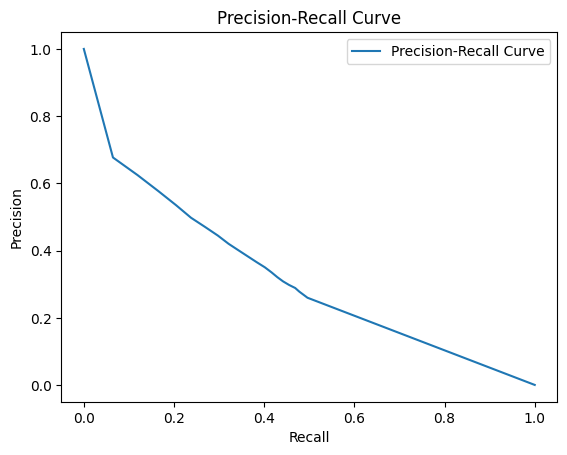

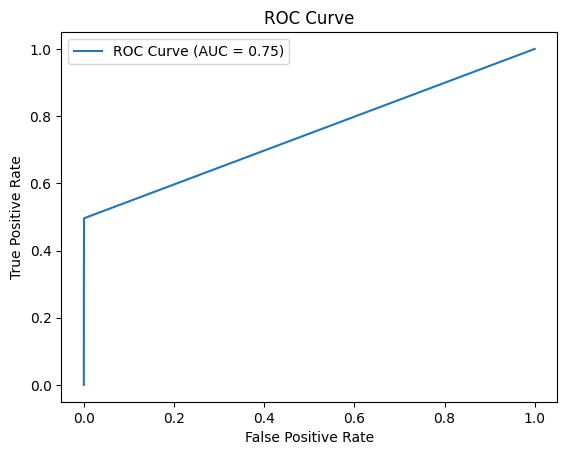

In [4]:
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
import faiss
from sklearn.metrics import precision_recall_curve, roc_curve, auc
import matplotlib.pyplot as plt

# Compute R@1, R@5, R@10, R@20
RECALL_VALUES = [1, 5, 10, 20]

def calculate_map(predictions, positives_per_query):
    average_precisions = []
    for query_index, preds in enumerate(predictions):
        relevant = set(positives_per_query[query_index])
        retrieved = preds
        num_relevant = len(relevant)
        
        if num_relevant == 0:
            continue
        
        precision_at_i = []
        num_hits = 0
        for i, pred in enumerate(retrieved):
            if pred in relevant:
                num_hits += 1
                precision_at_i.append(num_hits / (i + 1))
        
        if num_hits > 0:
            average_precisions.append(np.sum(precision_at_i) / num_hits)
        else:
            average_precisions.append(0.0)
    
    return np.mean(average_precisions)

def calculate_p_at_k(predictions, positives_per_query, k):
    precision_at_k = []
    for query_index, preds in enumerate(predictions):
        relevant = set(positives_per_query[query_index])
        retrieved = preds[:k]
        num_relevant = len(relevant)
        
        if num_relevant == 0:
            continue
        
        num_hits = len([pred for pred in retrieved if pred in relevant])
        precision_at_k.append(num_hits / k)
    
    return np.mean(precision_at_k)

def calculate_ndcg(predictions, positives_per_query, k):
    ndcg_scores = []
    for query_index, preds in enumerate(predictions):
        relevant = set(positives_per_query[query_index])
        retrieved = preds[:k]
        dcg = 0.0
        idcg = 0.0
        
        for i, pred in enumerate(retrieved):
            if pred in relevant:
                dcg += 1.0 / np.log2(i + 2)  # i+2 because log2(1) = 0
            
        for i in range(min(len(relevant), k)):
            idcg += 1.0 / np.log2(i + 2)
        
        ndcg_scores.append(dcg / idcg if idcg > 0 else 0.0)
    
    return np.mean(ndcg_scores)

def calculate_f1_at_k(precision, recall):
    return 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

def test(eval_ds, model, num_preds_to_save=0):
    model = model.eval()
    with torch.no_grad():
        print("Extracting database descriptors for evaluation/testing")
        database_subset_ds = Subset(eval_ds, list(range(eval_ds.database_num)))
        database_dataloader = DataLoader(dataset=database_subset_ds, batch_size=32, pin_memory=True)
        all_descriptors = np.empty((len(eval_ds), 512), dtype="float32")
        for images, indices in tqdm(database_dataloader, ncols=100):
            descriptors = model(images.to("cuda"))
            descriptors = descriptors.cpu().numpy()
            all_descriptors[indices.numpy(), :] = descriptors
        
        print("Extracting queries descriptors for evaluation/testing using batch size 1")
        queries_infer_batch_size = 1
        queries_subset_ds = Subset(eval_ds, list(range(eval_ds.database_num, eval_ds.database_num + eval_ds.queries_num)))
        queries_dataloader = DataLoader(dataset=queries_subset_ds, batch_size=queries_infer_batch_size, pin_memory=True)
        for images, indices in tqdm(queries_dataloader, ncols=100):
            descriptors = model(images.to("cuda"))
            descriptors = descriptors.cpu().numpy()
            all_descriptors[indices.numpy(), :] = descriptors
    
    queries_descriptors = all_descriptors[eval_ds.database_num:]
    database_descriptors = all_descriptors[:eval_ds.database_num]
    
    # Use a kNN to find predictions
    faiss_index = faiss.IndexFlatL2(512)
    faiss_index.add(database_descriptors)
    del database_descriptors, all_descriptors
    
    print("Calculating recalls and precisions")
    _, predictions = faiss_index.search(queries_descriptors, max(RECALL_VALUES))
    
    # Compute recall
    positives_per_query = eval_ds.get_positives()
    recalls = np.zeros(len(RECALL_VALUES))
    for query_index, preds in enumerate(predictions):
        for i, n in enumerate(RECALL_VALUES):
            if np.any(np.in1d(preds[:n], positives_per_query[query_index])):
                recalls[i:] += 1
                break
    
    recalls = recalls / eval_ds.queries_num * 100
    recalls_str = ", ".join([f"R@{val}: {rec:.1f}" for val, rec in zip(RECALL_VALUES, recalls)])
    
    # Compute precision at K
    precision_at_1 = calculate_p_at_k(predictions, positives_per_query, 1) * 100
    precision_at_5 = calculate_p_at_k(predictions, positives_per_query, 5) * 100
    precision_at_10 = calculate_p_at_k(predictions, positives_per_query, 10) * 100
    precision_at_20 = calculate_p_at_k(predictions, positives_per_query, 20) * 100
    
    # Compute mean average precision
    map_score = calculate_map(predictions, positives_per_query) * 100
    
    precisions_str = f"P@1: {precision_at_1:.2f}, P@5: {precision_at_5:.2f}, P@10: {precision_at_10:.2f}, P@20: {precision_at_20:.2f}"
    map_str = f"mAP: {map_score:.2f}"
    
    # Compute NDCG at K
    ndcg_at_1 = calculate_ndcg(predictions, positives_per_query, 1)
    ndcg_at_5 = calculate_ndcg(predictions, positives_per_query, 5)
    ndcg_at_10 = calculate_ndcg(predictions, positives_per_query, 10)
    ndcg_at_20 = calculate_ndcg(predictions, positives_per_query, 20)
    ndcg_str = f"NDCG@1: {ndcg_at_1:.2f}, NDCG@5: {ndcg_at_5:.2f}, NDCG@10: {ndcg_at_10:.2f}, NDCG@20: {ndcg_at_20:.2f}"
    
    # Compute F1@K
    f1_at_1 = calculate_f1_at_k(precision_at_1, recalls[0])
    f1_at_5 = calculate_f1_at_k(precision_at_5, recalls[1])
    f1_at_10 = calculate_f1_at_k(precision_at_10, recalls[2])
    f1_at_20 = calculate_f1_at_k(precision_at_20, recalls[3])
    f1_str = f"F1@1: {f1_at_1:.2f}, F1@5: {f1_at_5:.2f}, F1@10: {f1_at_10:.2f}, F1@20: {f1_at_20:.2f}"
    
    # Compute Precision-Recall and ROC Curve
    y_true = np.zeros((eval_ds.queries_num, eval_ds.database_num))
    for i, positives in enumerate(positives_per_query):
        y_true[i, positives] = 1
    
    y_scores = np.zeros((eval_ds.queries_num, eval_ds.database_num))
    for i, preds in enumerate(predictions):
        y_scores[i, preds] = 1 / (np.arange(len(preds)) + 1)
    
    precision, recall, _ = precision_recall_curve(y_true.ravel(), y_scores.ravel())
    fpr, tpr, _ = roc_curve(y_true.ravel(), y_scores.ravel())
    roc_auc = auc(fpr, tpr)
    auc_str = f"AUC: {roc_auc:.2f}"
    
    print(recalls_str)
    print(precisions_str)
    print(ndcg_str)
    print(f1_str)
    print(map_str)
    print(auc_str)
    
    return recalls, recalls_str, precisions_str, ndcg_str, f1_str, map_str, auc_str, precision, recall, fpr, tpr, roc_auc

# Assuming you have the Dataset and DataLoader set up as in your original code
# And assuming `model` is your trained model
test_ds = TestDataset("small/test", queries_folder="queries_v1")
recalls, recalls_str, precisions_str, ndcg_str, f1_str, map_str, auc_str, precision, recall, fpr, tpr, roc_auc = test(test_ds, model, 3)

print(recalls_str)
print(precisions_str)
print(ndcg_str)
print(f1_str)
print(map_str)
print(auc_str)

# Plot Precision-Recall Curve
plt.figure()
plt.plot(recall, precision, label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
plt.show()

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='best')
plt.show()

## Resnet 50 dim 512

In [5]:
model = torch.hub.load("gmberton/cosplace", "get_trained_model", backbone="ResNet50", fc_output_dim=512)
model.to("cuda")

Using cache found in C:\Users\chiga/.cache\torch\hub\gmberton_cosplace_main


Returning CosPlace model with backbone: ResNet50 with features dimension 512


Downloading: "https://github.com/gmberton/CosPlace/releases/download/v1.0/ResNet50_512_cosplace.pth" to C:\Users\chiga/.cache\torch\hub\checkpoints\ResNet50_512_cosplace.pth
100%|██████████| 94.0M/94.0M [01:08<00:00, 1.44MB/s]


GeoLocalizationNet(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0):

Extracting database descriptors for evaluation/testing


100%|█████████████████████████████████████████████████████████████| 850/850 [09:28<00:00,  1.50it/s]


Extracting queries descriptors for evaluation/testing using batch size 1


100%|███████████████████████████████████████████████████████████| 1000/1000 [00:37<00:00, 26.95it/s]


Calculating recalls and precisions
R@1: 75.3, R@5: 82.8, R@10: 85.7, R@20: 88.3
P@1: 77.95, P@5: 58.92, P@10: 45.25, P@20: 30.17
NDCG@1: 0.75, NDCG@5: 0.65, NDCG@10: 0.61, NDCG@20: 0.61
F1@1: 76.60, F1@5: 68.85, F1@10: 59.23, F1@20: 44.97
mAP: 70.68
AUC: 0.78
R@1: 75.3, R@5: 82.8, R@10: 85.7, R@20: 88.3
P@1: 77.95, P@5: 58.92, P@10: 45.25, P@20: 30.17
NDCG@1: 0.75, NDCG@5: 0.65, NDCG@10: 0.61, NDCG@20: 0.61
F1@1: 76.60, F1@5: 68.85, F1@10: 59.23, F1@20: 44.97
mAP: 70.68
AUC: 0.78


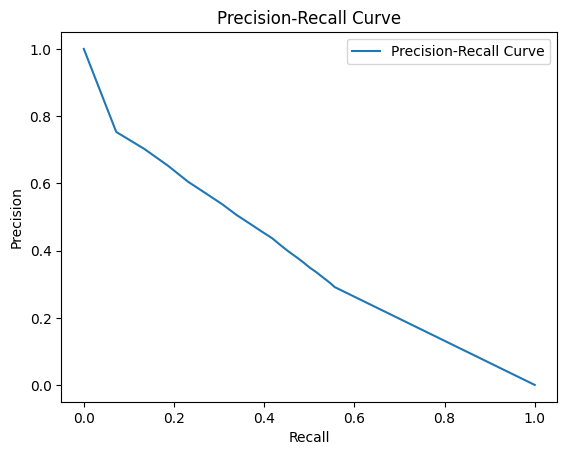

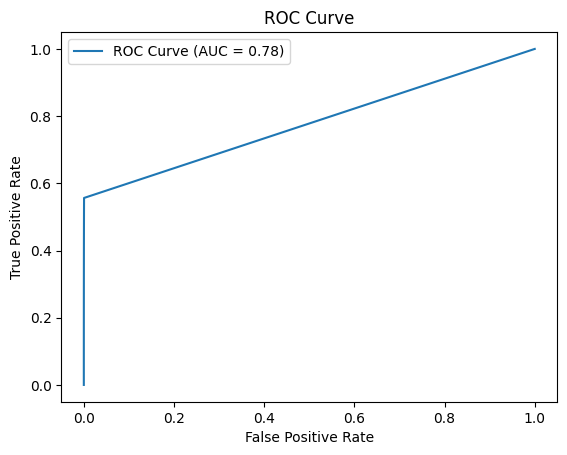

In [6]:
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
import faiss
from sklearn.metrics import precision_recall_curve, roc_curve, auc
import matplotlib.pyplot as plt

# Compute R@1, R@5, R@10, R@20
RECALL_VALUES = [1, 5, 10, 20]

def calculate_map(predictions, positives_per_query):
    average_precisions = []
    for query_index, preds in enumerate(predictions):
        relevant = set(positives_per_query[query_index])
        retrieved = preds
        num_relevant = len(relevant)
        
        if num_relevant == 0:
            continue
        
        precision_at_i = []
        num_hits = 0
        for i, pred in enumerate(retrieved):
            if pred in relevant:
                num_hits += 1
                precision_at_i.append(num_hits / (i + 1))
        
        if num_hits > 0:
            average_precisions.append(np.sum(precision_at_i) / num_hits)
        else:
            average_precisions.append(0.0)
    
    return np.mean(average_precisions)

def calculate_p_at_k(predictions, positives_per_query, k):
    precision_at_k = []
    for query_index, preds in enumerate(predictions):
        relevant = set(positives_per_query[query_index])
        retrieved = preds[:k]
        num_relevant = len(relevant)
        
        if num_relevant == 0:
            continue
        
        num_hits = len([pred for pred in retrieved if pred in relevant])
        precision_at_k.append(num_hits / k)
    
    return np.mean(precision_at_k)

def calculate_ndcg(predictions, positives_per_query, k):
    ndcg_scores = []
    for query_index, preds in enumerate(predictions):
        relevant = set(positives_per_query[query_index])
        retrieved = preds[:k]
        dcg = 0.0
        idcg = 0.0
        
        for i, pred in enumerate(retrieved):
            if pred in relevant:
                dcg += 1.0 / np.log2(i + 2)  # i+2 because log2(1) = 0
            
        for i in range(min(len(relevant), k)):
            idcg += 1.0 / np.log2(i + 2)
        
        ndcg_scores.append(dcg / idcg if idcg > 0 else 0.0)
    
    return np.mean(ndcg_scores)

def calculate_f1_at_k(precision, recall):
    return 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

def test(eval_ds, model, num_preds_to_save=0):
    model = model.eval()
    with torch.no_grad():
        print("Extracting database descriptors for evaluation/testing")
        database_subset_ds = Subset(eval_ds, list(range(eval_ds.database_num)))
        database_dataloader = DataLoader(dataset=database_subset_ds, batch_size=32, pin_memory=True)
        all_descriptors = np.empty((len(eval_ds), 512), dtype="float32")
        for images, indices in tqdm(database_dataloader, ncols=100):
            descriptors = model(images.to("cuda"))
            descriptors = descriptors.cpu().numpy()
            all_descriptors[indices.numpy(), :] = descriptors
        
        print("Extracting queries descriptors for evaluation/testing using batch size 1")
        queries_infer_batch_size = 1
        queries_subset_ds = Subset(eval_ds, list(range(eval_ds.database_num, eval_ds.database_num + eval_ds.queries_num)))
        queries_dataloader = DataLoader(dataset=queries_subset_ds, batch_size=queries_infer_batch_size, pin_memory=True)
        for images, indices in tqdm(queries_dataloader, ncols=100):
            descriptors = model(images.to("cuda"))
            descriptors = descriptors.cpu().numpy()
            all_descriptors[indices.numpy(), :] = descriptors
    
    queries_descriptors = all_descriptors[eval_ds.database_num:]
    database_descriptors = all_descriptors[:eval_ds.database_num]
    
    # Use a kNN to find predictions
    faiss_index = faiss.IndexFlatL2(512)
    faiss_index.add(database_descriptors)
    del database_descriptors, all_descriptors
    
    print("Calculating recalls and precisions")
    _, predictions = faiss_index.search(queries_descriptors, max(RECALL_VALUES))
    
    # Compute recall
    positives_per_query = eval_ds.get_positives()
    recalls = np.zeros(len(RECALL_VALUES))
    for query_index, preds in enumerate(predictions):
        for i, n in enumerate(RECALL_VALUES):
            if np.any(np.in1d(preds[:n], positives_per_query[query_index])):
                recalls[i:] += 1
                break
    
    recalls = recalls / eval_ds.queries_num * 100
    recalls_str = ", ".join([f"R@{val}: {rec:.1f}" for val, rec in zip(RECALL_VALUES, recalls)])
    
    # Compute precision at K
    precision_at_1 = calculate_p_at_k(predictions, positives_per_query, 1) * 100
    precision_at_5 = calculate_p_at_k(predictions, positives_per_query, 5) * 100
    precision_at_10 = calculate_p_at_k(predictions, positives_per_query, 10) * 100
    precision_at_20 = calculate_p_at_k(predictions, positives_per_query, 20) * 100
    
    # Compute mean average precision
    map_score = calculate_map(predictions, positives_per_query) * 100
    
    precisions_str = f"P@1: {precision_at_1:.2f}, P@5: {precision_at_5:.2f}, P@10: {precision_at_10:.2f}, P@20: {precision_at_20:.2f}"
    map_str = f"mAP: {map_score:.2f}"
    
    # Compute NDCG at K
    ndcg_at_1 = calculate_ndcg(predictions, positives_per_query, 1)
    ndcg_at_5 = calculate_ndcg(predictions, positives_per_query, 5)
    ndcg_at_10 = calculate_ndcg(predictions, positives_per_query, 10)
    ndcg_at_20 = calculate_ndcg(predictions, positives_per_query, 20)
    ndcg_str = f"NDCG@1: {ndcg_at_1:.2f}, NDCG@5: {ndcg_at_5:.2f}, NDCG@10: {ndcg_at_10:.2f}, NDCG@20: {ndcg_at_20:.2f}"
    
    # Compute F1@K
    f1_at_1 = calculate_f1_at_k(precision_at_1, recalls[0])
    f1_at_5 = calculate_f1_at_k(precision_at_5, recalls[1])
    f1_at_10 = calculate_f1_at_k(precision_at_10, recalls[2])
    f1_at_20 = calculate_f1_at_k(precision_at_20, recalls[3])
    f1_str = f"F1@1: {f1_at_1:.2f}, F1@5: {f1_at_5:.2f}, F1@10: {f1_at_10:.2f}, F1@20: {f1_at_20:.2f}"
    
    # Compute Precision-Recall and ROC Curve
    y_true = np.zeros((eval_ds.queries_num, eval_ds.database_num))
    for i, positives in enumerate(positives_per_query):
        y_true[i, positives] = 1
    
    y_scores = np.zeros((eval_ds.queries_num, eval_ds.database_num))
    for i, preds in enumerate(predictions):
        y_scores[i, preds] = 1 / (np.arange(len(preds)) + 1)
    
    precision, recall, _ = precision_recall_curve(y_true.ravel(), y_scores.ravel())
    fpr, tpr, _ = roc_curve(y_true.ravel(), y_scores.ravel())
    roc_auc = auc(fpr, tpr)
    auc_str = f"AUC: {roc_auc:.2f}"
    
    print(recalls_str)
    print(precisions_str)
    print(ndcg_str)
    print(f1_str)
    print(map_str)
    print(auc_str)
    
    return recalls, recalls_str, precisions_str, ndcg_str, f1_str, map_str, auc_str, precision, recall, fpr, tpr, roc_auc

# Assuming you have the Dataset and DataLoader set up as in your original code
# And assuming `model` is your trained model
test_ds = TestDataset("small/test", queries_folder="queries_v1")
recalls, recalls_str, precisions_str, ndcg_str, f1_str, map_str, auc_str, precision, recall, fpr, tpr, roc_auc = test(test_ds, model, 3)

print(recalls_str)
print(precisions_str)
print(ndcg_str)
print(f1_str)
print(map_str)
print(auc_str)

# Plot Precision-Recall Curve
plt.figure()
plt.plot(recall, precision, label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
plt.show()

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='best')
plt.show()

# Val dataset

## Resnet50 dim 2048

In [7]:
model = torch.hub.load("gmberton/cosplace", "get_trained_model", backbone="ResNet50", fc_output_dim=2048)
model.to("cuda")

Using cache found in C:\Users\chiga/.cache\torch\hub\gmberton_cosplace_main


Returning CosPlace model with backbone: ResNet50 with features dimension 2048


GeoLocalizationNet(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0):

Extracting database descriptors for evaluation/testing


100%|█████████████████████████████████████████████████████████████| 251/251 [03:55<00:00,  1.07it/s]


Extracting queries descriptors for evaluation/testing using batch size 1


100%|███████████████████████████████████████████████████████████| 7993/7993 [14:30<00:00,  9.18it/s]


Calculating recalls and precisions
R@1: 94.6, R@5: 97.6, R@10: 98.3, R@20: 98.7
P@1: 94.57, P@5: 43.93, P@10: 24.36, P@20: 13.30
NDCG@1: 0.95, NDCG@5: 0.56, NDCG@10: 0.40, NDCG@20: 0.41
F1@1: 94.57, F1@5: 60.59, F1@10: 39.05, F1@20: 23.44
mAP: 84.34
AUC: 0.64
R@1: 94.6, R@5: 97.6, R@10: 98.3, R@20: 98.7
P@1: 94.57, P@5: 43.93, P@10: 24.36, P@20: 13.30
NDCG@1: 0.95, NDCG@5: 0.56, NDCG@10: 0.40, NDCG@20: 0.41
F1@1: 94.57, F1@5: 60.59, F1@10: 39.05, F1@20: 23.44
mAP: 84.34
AUC: 0.64


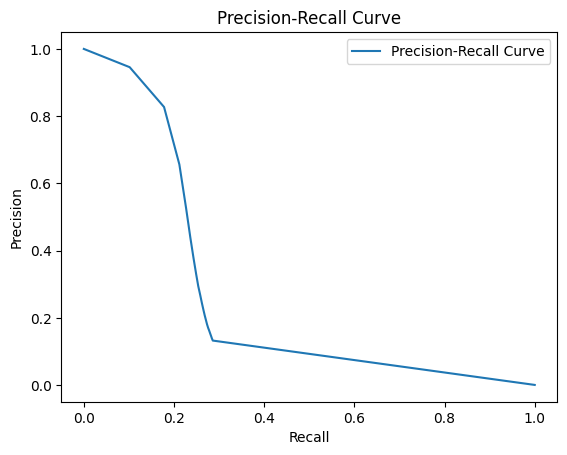

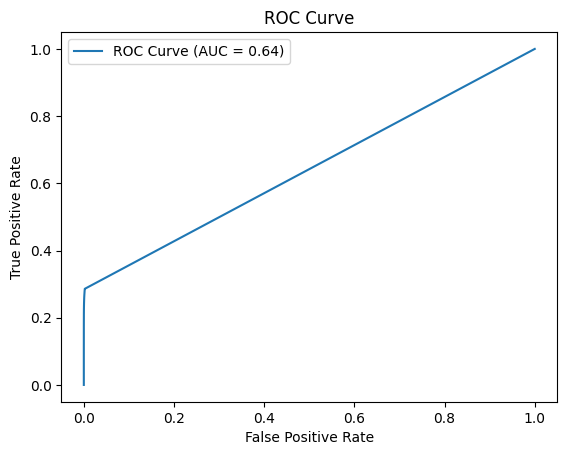

In [8]:
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
import faiss
from sklearn.metrics import precision_recall_curve, roc_curve, auc
import matplotlib.pyplot as plt

# Compute R@1, R@5, R@10, R@20
RECALL_VALUES = [1, 5, 10, 20]

def calculate_map(predictions, positives_per_query):
    average_precisions = []
    for query_index, preds in enumerate(predictions):
        relevant = set(positives_per_query[query_index])
        retrieved = preds
        num_relevant = len(relevant)
        
        if num_relevant == 0:
            continue
        
        precision_at_i = []
        num_hits = 0
        for i, pred in enumerate(retrieved):
            if pred in relevant:
                num_hits += 1
                precision_at_i.append(num_hits / (i + 1))
        
        if num_hits > 0:
            average_precisions.append(np.sum(precision_at_i) / num_hits)
        else:
            average_precisions.append(0.0)
    
    return np.mean(average_precisions)

def calculate_p_at_k(predictions, positives_per_query, k):
    precision_at_k = []
    for query_index, preds in enumerate(predictions):
        relevant = set(positives_per_query[query_index])
        retrieved = preds[:k]
        num_relevant = len(relevant)
        
        if num_relevant == 0:
            continue
        
        num_hits = len([pred for pred in retrieved if pred in relevant])
        precision_at_k.append(num_hits / k)
    
    return np.mean(precision_at_k)

def calculate_ndcg(predictions, positives_per_query, k):
    ndcg_scores = []
    for query_index, preds in enumerate(predictions):
        relevant = set(positives_per_query[query_index])
        retrieved = preds[:k]
        dcg = 0.0
        idcg = 0.0
        
        for i, pred in enumerate(retrieved):
            if pred in relevant:
                dcg += 1.0 / np.log2(i + 2)  # i+2 because log2(1) = 0
            
        for i in range(min(len(relevant), k)):
            idcg += 1.0 / np.log2(i + 2)
        
        ndcg_scores.append(dcg / idcg if idcg > 0 else 0.0)
    
    return np.mean(ndcg_scores)

def calculate_f1_at_k(precision, recall):
    return 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

def test(eval_ds, model, num_preds_to_save=0):
    model = model.eval()
    with torch.no_grad():
        print("Extracting database descriptors for evaluation/testing")
        database_subset_ds = Subset(eval_ds, list(range(eval_ds.database_num)))
        database_dataloader = DataLoader(dataset=database_subset_ds, batch_size=32, pin_memory=True)
        all_descriptors = np.empty((len(eval_ds), 2048), dtype="float32")
        for images, indices in tqdm(database_dataloader, ncols=100):
            descriptors = model(images.to("cuda"))
            descriptors = descriptors.cpu().numpy()
            all_descriptors[indices.numpy(), :] = descriptors
        
        print("Extracting queries descriptors for evaluation/testing using batch size 1")
        queries_infer_batch_size = 1
        queries_subset_ds = Subset(eval_ds, list(range(eval_ds.database_num, eval_ds.database_num + eval_ds.queries_num)))
        queries_dataloader = DataLoader(dataset=queries_subset_ds, batch_size=queries_infer_batch_size, pin_memory=True)
        for images, indices in tqdm(queries_dataloader, ncols=100):
            descriptors = model(images.to("cuda"))
            descriptors = descriptors.cpu().numpy()
            all_descriptors[indices.numpy(), :] = descriptors
    
    queries_descriptors = all_descriptors[eval_ds.database_num:]
    database_descriptors = all_descriptors[:eval_ds.database_num]
    
    # Use a kNN to find predictions
    faiss_index = faiss.IndexFlatL2(2048)
    faiss_index.add(database_descriptors)
    del database_descriptors, all_descriptors
    
    print("Calculating recalls and precisions")
    _, predictions = faiss_index.search(queries_descriptors, max(RECALL_VALUES))
    
    # Compute recall
    positives_per_query = eval_ds.get_positives()
    recalls = np.zeros(len(RECALL_VALUES))
    for query_index, preds in enumerate(predictions):
        for i, n in enumerate(RECALL_VALUES):
            if np.any(np.in1d(preds[:n], positives_per_query[query_index])):
                recalls[i:] += 1
                break
    
    recalls = recalls / eval_ds.queries_num * 100
    recalls_str = ", ".join([f"R@{val}: {rec:.1f}" for val, rec in zip(RECALL_VALUES, recalls)])
    
    # Compute precision at K
    precision_at_1 = calculate_p_at_k(predictions, positives_per_query, 1) * 100
    precision_at_5 = calculate_p_at_k(predictions, positives_per_query, 5) * 100
    precision_at_10 = calculate_p_at_k(predictions, positives_per_query, 10) * 100
    precision_at_20 = calculate_p_at_k(predictions, positives_per_query, 20) * 100
    
    # Compute mean average precision
    map_score = calculate_map(predictions, positives_per_query) * 100
    
    precisions_str = f"P@1: {precision_at_1:.2f}, P@5: {precision_at_5:.2f}, P@10: {precision_at_10:.2f}, P@20: {precision_at_20:.2f}"
    map_str = f"mAP: {map_score:.2f}"
    
    # Compute NDCG at K
    ndcg_at_1 = calculate_ndcg(predictions, positives_per_query, 1)
    ndcg_at_5 = calculate_ndcg(predictions, positives_per_query, 5)
    ndcg_at_10 = calculate_ndcg(predictions, positives_per_query, 10)
    ndcg_at_20 = calculate_ndcg(predictions, positives_per_query, 20)
    ndcg_str = f"NDCG@1: {ndcg_at_1:.2f}, NDCG@5: {ndcg_at_5:.2f}, NDCG@10: {ndcg_at_10:.2f}, NDCG@20: {ndcg_at_20:.2f}"
    
    # Compute F1@K
    f1_at_1 = calculate_f1_at_k(precision_at_1, recalls[0])
    f1_at_5 = calculate_f1_at_k(precision_at_5, recalls[1])
    f1_at_10 = calculate_f1_at_k(precision_at_10, recalls[2])
    f1_at_20 = calculate_f1_at_k(precision_at_20, recalls[3])
    f1_str = f"F1@1: {f1_at_1:.2f}, F1@5: {f1_at_5:.2f}, F1@10: {f1_at_10:.2f}, F1@20: {f1_at_20:.2f}"
    
    # Compute Precision-Recall and ROC Curve
    y_true = np.zeros((eval_ds.queries_num, eval_ds.database_num))
    for i, positives in enumerate(positives_per_query):
        y_true[i, positives] = 1
    
    y_scores = np.zeros((eval_ds.queries_num, eval_ds.database_num))
    for i, preds in enumerate(predictions):
        y_scores[i, preds] = 1 / (np.arange(len(preds)) + 1)
    
    precision, recall, _ = precision_recall_curve(y_true.ravel(), y_scores.ravel())
    fpr, tpr, _ = roc_curve(y_true.ravel(), y_scores.ravel())
    roc_auc = auc(fpr, tpr)
    auc_str = f"AUC: {roc_auc:.2f}"
    
    print(recalls_str)
    print(precisions_str)
    print(ndcg_str)
    print(f1_str)
    print(map_str)
    print(auc_str)
    
    return recalls, recalls_str, precisions_str, ndcg_str, f1_str, map_str, auc_str, precision, recall, fpr, tpr, roc_auc

# Assuming you have the Dataset and DataLoader set up as in your original code
# And assuming `model` is your trained model
test_ds = TestDataset("small/val", queries_folder="queries")
recalls, recalls_str, precisions_str, ndcg_str, f1_str, map_str, auc_str, precision, recall, fpr, tpr, roc_auc = test(test_ds, model, 3)

print(recalls_str)
print(precisions_str)
print(ndcg_str)
print(f1_str)
print(map_str)
print(auc_str)

# Plot Precision-Recall Curve
plt.figure()
plt.plot(recall, precision, label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
plt.show()

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='best')
plt.show()

## Resnet 18 dim 512

In [9]:
model = torch.hub.load("gmberton/cosplace", "get_trained_model", backbone="ResNet18", fc_output_dim=512)
model.to("cuda")

Using cache found in C:\Users\chiga/.cache\torch\hub\gmberton_cosplace_main


Returning CosPlace model with backbone: ResNet18 with features dimension 512


GeoLocalizationNet(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running

Extracting database descriptors for evaluation/testing


100%|█████████████████████████████████████████████████████████████| 251/251 [05:38<00:00,  1.35s/it]


Extracting queries descriptors for evaluation/testing using batch size 1


100%|███████████████████████████████████████████████████████████| 7993/7993 [04:55<00:00, 27.04it/s]


Calculating recalls and precisions
R@1: 90.7, R@5: 95.8, R@10: 96.8, R@20: 97.7
P@1: 90.72, P@5: 39.62, P@10: 22.24, P@20: 12.27
NDCG@1: 0.91, NDCG@5: 0.51, NDCG@10: 0.37, NDCG@20: 0.38
F1@1: 90.72, F1@5: 56.05, F1@10: 36.16, F1@20: 21.81
mAP: 80.25
AUC: 0.63
R@1: 90.7, R@5: 95.8, R@10: 96.8, R@20: 97.7
P@1: 90.72, P@5: 39.62, P@10: 22.24, P@20: 12.27
NDCG@1: 0.91, NDCG@5: 0.51, NDCG@10: 0.37, NDCG@20: 0.38
F1@1: 90.72, F1@5: 56.05, F1@10: 36.16, F1@20: 21.81
mAP: 80.25
AUC: 0.63


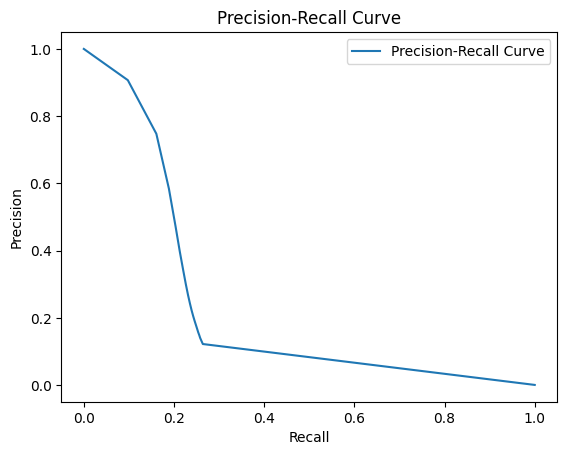

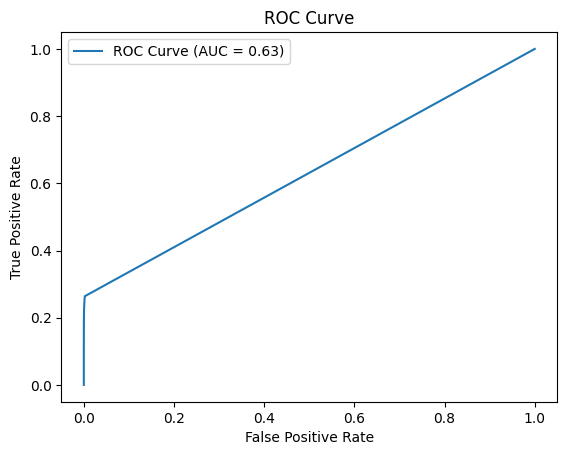

In [10]:
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
import faiss
from sklearn.metrics import precision_recall_curve, roc_curve, auc
import matplotlib.pyplot as plt

# Compute R@1, R@5, R@10, R@20
RECALL_VALUES = [1, 5, 10, 20]

def calculate_map(predictions, positives_per_query):
    average_precisions = []
    for query_index, preds in enumerate(predictions):
        relevant = set(positives_per_query[query_index])
        retrieved = preds
        num_relevant = len(relevant)
        
        if num_relevant == 0:
            continue
        
        precision_at_i = []
        num_hits = 0
        for i, pred in enumerate(retrieved):
            if pred in relevant:
                num_hits += 1
                precision_at_i.append(num_hits / (i + 1))
        
        if num_hits > 0:
            average_precisions.append(np.sum(precision_at_i) / num_hits)
        else:
            average_precisions.append(0.0)
    
    return np.mean(average_precisions)

def calculate_p_at_k(predictions, positives_per_query, k):
    precision_at_k = []
    for query_index, preds in enumerate(predictions):
        relevant = set(positives_per_query[query_index])
        retrieved = preds[:k]
        num_relevant = len(relevant)
        
        if num_relevant == 0:
            continue
        
        num_hits = len([pred for pred in retrieved if pred in relevant])
        precision_at_k.append(num_hits / k)
    
    return np.mean(precision_at_k)

def calculate_ndcg(predictions, positives_per_query, k):
    ndcg_scores = []
    for query_index, preds in enumerate(predictions):
        relevant = set(positives_per_query[query_index])
        retrieved = preds[:k]
        dcg = 0.0
        idcg = 0.0
        
        for i, pred in enumerate(retrieved):
            if pred in relevant:
                dcg += 1.0 / np.log2(i + 2)  # i+2 because log2(1) = 0
            
        for i in range(min(len(relevant), k)):
            idcg += 1.0 / np.log2(i + 2)
        
        ndcg_scores.append(dcg / idcg if idcg > 0 else 0.0)
    
    return np.mean(ndcg_scores)

def calculate_f1_at_k(precision, recall):
    return 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

def test(eval_ds, model, num_preds_to_save=0):
    model = model.eval()
    with torch.no_grad():
        print("Extracting database descriptors for evaluation/testing")
        database_subset_ds = Subset(eval_ds, list(range(eval_ds.database_num)))
        database_dataloader = DataLoader(dataset=database_subset_ds, batch_size=32, pin_memory=True)
        all_descriptors = np.empty((len(eval_ds), 512), dtype="float32")
        for images, indices in tqdm(database_dataloader, ncols=100):
            descriptors = model(images.to("cuda"))
            descriptors = descriptors.cpu().numpy()
            all_descriptors[indices.numpy(), :] = descriptors
        
        print("Extracting queries descriptors for evaluation/testing using batch size 1")
        queries_infer_batch_size = 1
        queries_subset_ds = Subset(eval_ds, list(range(eval_ds.database_num, eval_ds.database_num + eval_ds.queries_num)))
        queries_dataloader = DataLoader(dataset=queries_subset_ds, batch_size=queries_infer_batch_size, pin_memory=True)
        for images, indices in tqdm(queries_dataloader, ncols=100):
            descriptors = model(images.to("cuda"))
            descriptors = descriptors.cpu().numpy()
            all_descriptors[indices.numpy(), :] = descriptors
    
    queries_descriptors = all_descriptors[eval_ds.database_num:]
    database_descriptors = all_descriptors[:eval_ds.database_num]
    
    # Use a kNN to find predictions
    faiss_index = faiss.IndexFlatL2(512)
    faiss_index.add(database_descriptors)
    del database_descriptors, all_descriptors
    
    print("Calculating recalls and precisions")
    _, predictions = faiss_index.search(queries_descriptors, max(RECALL_VALUES))
    
    # Compute recall
    positives_per_query = eval_ds.get_positives()
    recalls = np.zeros(len(RECALL_VALUES))
    for query_index, preds in enumerate(predictions):
        for i, n in enumerate(RECALL_VALUES):
            if np.any(np.in1d(preds[:n], positives_per_query[query_index])):
                recalls[i:] += 1
                break
    
    recalls = recalls / eval_ds.queries_num * 100
    recalls_str = ", ".join([f"R@{val}: {rec:.1f}" for val, rec in zip(RECALL_VALUES, recalls)])
    
    # Compute precision at K
    precision_at_1 = calculate_p_at_k(predictions, positives_per_query, 1) * 100
    precision_at_5 = calculate_p_at_k(predictions, positives_per_query, 5) * 100
    precision_at_10 = calculate_p_at_k(predictions, positives_per_query, 10) * 100
    precision_at_20 = calculate_p_at_k(predictions, positives_per_query, 20) * 100
    
    # Compute mean average precision
    map_score = calculate_map(predictions, positives_per_query) * 100
    
    precisions_str = f"P@1: {precision_at_1:.2f}, P@5: {precision_at_5:.2f}, P@10: {precision_at_10:.2f}, P@20: {precision_at_20:.2f}"
    map_str = f"mAP: {map_score:.2f}"
    
    # Compute NDCG at K
    ndcg_at_1 = calculate_ndcg(predictions, positives_per_query, 1)
    ndcg_at_5 = calculate_ndcg(predictions, positives_per_query, 5)
    ndcg_at_10 = calculate_ndcg(predictions, positives_per_query, 10)
    ndcg_at_20 = calculate_ndcg(predictions, positives_per_query, 20)
    ndcg_str = f"NDCG@1: {ndcg_at_1:.2f}, NDCG@5: {ndcg_at_5:.2f}, NDCG@10: {ndcg_at_10:.2f}, NDCG@20: {ndcg_at_20:.2f}"
    
    # Compute F1@K
    f1_at_1 = calculate_f1_at_k(precision_at_1, recalls[0])
    f1_at_5 = calculate_f1_at_k(precision_at_5, recalls[1])
    f1_at_10 = calculate_f1_at_k(precision_at_10, recalls[2])
    f1_at_20 = calculate_f1_at_k(precision_at_20, recalls[3])
    f1_str = f"F1@1: {f1_at_1:.2f}, F1@5: {f1_at_5:.2f}, F1@10: {f1_at_10:.2f}, F1@20: {f1_at_20:.2f}"
    
    # Compute Precision-Recall and ROC Curve
    y_true = np.zeros((eval_ds.queries_num, eval_ds.database_num))
    for i, positives in enumerate(positives_per_query):
        y_true[i, positives] = 1
    
    y_scores = np.zeros((eval_ds.queries_num, eval_ds.database_num))
    for i, preds in enumerate(predictions):
        y_scores[i, preds] = 1 / (np.arange(len(preds)) + 1)
    
    precision, recall, _ = precision_recall_curve(y_true.ravel(), y_scores.ravel())
    fpr, tpr, _ = roc_curve(y_true.ravel(), y_scores.ravel())
    roc_auc = auc(fpr, tpr)
    auc_str = f"AUC: {roc_auc:.2f}"
    
    print(recalls_str)
    print(precisions_str)
    print(ndcg_str)
    print(f1_str)
    print(map_str)
    print(auc_str)
    
    return recalls, recalls_str, precisions_str, ndcg_str, f1_str, map_str, auc_str, precision, recall, fpr, tpr, roc_auc

# Assuming you have the Dataset and DataLoader set up as in your original code
# And assuming `model` is your trained model
test_ds = TestDataset("small/val", queries_folder="queries")
recalls, recalls_str, precisions_str, ndcg_str, f1_str, map_str, auc_str, precision, recall, fpr, tpr, roc_auc = test(test_ds, model, 3)

print(recalls_str)
print(precisions_str)
print(ndcg_str)
print(f1_str)
print(map_str)
print(auc_str)

# Plot Precision-Recall Curve
plt.figure()
plt.plot(recall, precision, label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
plt.show()

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='best')
plt.show()

## Resnet 50 dim 512

In [11]:
model = torch.hub.load("gmberton/cosplace", "get_trained_model", backbone="ResNet50", fc_output_dim=512)
model.to("cuda")

Using cache found in C:\Users\chiga/.cache\torch\hub\gmberton_cosplace_main


Returning CosPlace model with backbone: ResNet50 with features dimension 512


GeoLocalizationNet(
  (backbone): Sequential(
    (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (4): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential(
          (0):

Extracting database descriptors for evaluation/testing


100%|█████████████████████████████████████████████████████████████| 251/251 [02:31<00:00,  1.66it/s]


Extracting queries descriptors for evaluation/testing using batch size 1


100%|███████████████████████████████████████████████████████████| 7993/7993 [03:39<00:00, 36.48it/s]


Calculating recalls and precisions
R@1: 94.3, R@5: 97.6, R@10: 98.2, R@20: 98.6
P@1: 94.28, P@5: 43.22, P@10: 24.00, P@20: 13.12
NDCG@1: 0.94, NDCG@5: 0.55, NDCG@10: 0.39, NDCG@20: 0.40
F1@1: 94.28, F1@5: 59.90, F1@10: 38.57, F1@20: 23.15
mAP: 84.07
AUC: 0.64
R@1: 94.3, R@5: 97.6, R@10: 98.2, R@20: 98.6
P@1: 94.28, P@5: 43.22, P@10: 24.00, P@20: 13.12
NDCG@1: 0.94, NDCG@5: 0.55, NDCG@10: 0.39, NDCG@20: 0.40
F1@1: 94.28, F1@5: 59.90, F1@10: 38.57, F1@20: 23.15
mAP: 84.07
AUC: 0.64


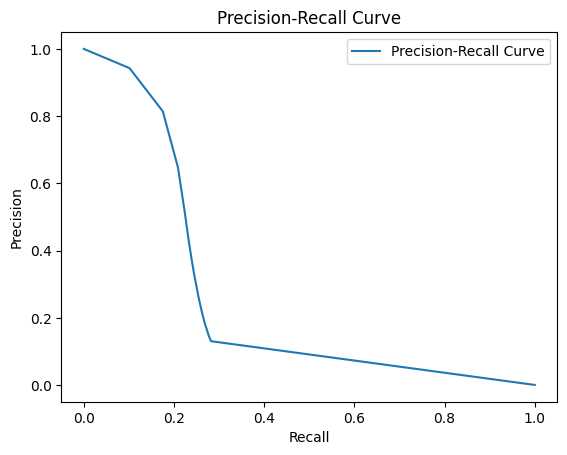

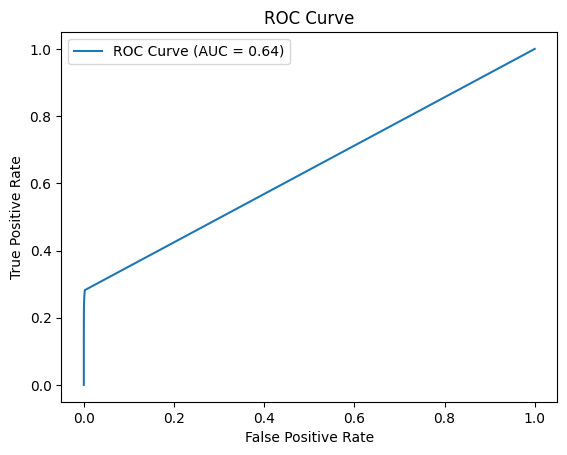

In [12]:
import numpy as np
import torch
from torch.utils.data import DataLoader, Subset
from tqdm import tqdm
import faiss
from sklearn.metrics import precision_recall_curve, roc_curve, auc
import matplotlib.pyplot as plt

# Compute R@1, R@5, R@10, R@20
RECALL_VALUES = [1, 5, 10, 20]

def calculate_map(predictions, positives_per_query):
    average_precisions = []
    for query_index, preds in enumerate(predictions):
        relevant = set(positives_per_query[query_index])
        retrieved = preds
        num_relevant = len(relevant)
        
        if num_relevant == 0:
            continue
        
        precision_at_i = []
        num_hits = 0
        for i, pred in enumerate(retrieved):
            if pred in relevant:
                num_hits += 1
                precision_at_i.append(num_hits / (i + 1))
        
        if num_hits > 0:
            average_precisions.append(np.sum(precision_at_i) / num_hits)
        else:
            average_precisions.append(0.0)
    
    return np.mean(average_precisions)

def calculate_p_at_k(predictions, positives_per_query, k):
    precision_at_k = []
    for query_index, preds in enumerate(predictions):
        relevant = set(positives_per_query[query_index])
        retrieved = preds[:k]
        num_relevant = len(relevant)
        
        if num_relevant == 0:
            continue
        
        num_hits = len([pred for pred in retrieved if pred in relevant])
        precision_at_k.append(num_hits / k)
    
    return np.mean(precision_at_k)

def calculate_ndcg(predictions, positives_per_query, k):
    ndcg_scores = []
    for query_index, preds in enumerate(predictions):
        relevant = set(positives_per_query[query_index])
        retrieved = preds[:k]
        dcg = 0.0
        idcg = 0.0
        
        for i, pred in enumerate(retrieved):
            if pred in relevant:
                dcg += 1.0 / np.log2(i + 2)  # i+2 because log2(1) = 0
            
        for i in range(min(len(relevant), k)):
            idcg += 1.0 / np.log2(i + 2)
        
        ndcg_scores.append(dcg / idcg if idcg > 0 else 0.0)
    
    return np.mean(ndcg_scores)

def calculate_f1_at_k(precision, recall):
    return 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0.0

def test(eval_ds, model, num_preds_to_save=0):
    model = model.eval()
    with torch.no_grad():
        print("Extracting database descriptors for evaluation/testing")
        database_subset_ds = Subset(eval_ds, list(range(eval_ds.database_num)))
        database_dataloader = DataLoader(dataset=database_subset_ds, batch_size=32, pin_memory=True)
        all_descriptors = np.empty((len(eval_ds), 512), dtype="float32")
        for images, indices in tqdm(database_dataloader, ncols=100):
            descriptors = model(images.to("cuda"))
            descriptors = descriptors.cpu().numpy()
            all_descriptors[indices.numpy(), :] = descriptors
        
        print("Extracting queries descriptors for evaluation/testing using batch size 1")
        queries_infer_batch_size = 1
        queries_subset_ds = Subset(eval_ds, list(range(eval_ds.database_num, eval_ds.database_num + eval_ds.queries_num)))
        queries_dataloader = DataLoader(dataset=queries_subset_ds, batch_size=queries_infer_batch_size, pin_memory=True)
        for images, indices in tqdm(queries_dataloader, ncols=100):
            descriptors = model(images.to("cuda"))
            descriptors = descriptors.cpu().numpy()
            all_descriptors[indices.numpy(), :] = descriptors
    
    queries_descriptors = all_descriptors[eval_ds.database_num:]
    database_descriptors = all_descriptors[:eval_ds.database_num]
    
    # Use a kNN to find predictions
    faiss_index = faiss.IndexFlatL2(512)
    faiss_index.add(database_descriptors)
    del database_descriptors, all_descriptors
    
    print("Calculating recalls and precisions")
    _, predictions = faiss_index.search(queries_descriptors, max(RECALL_VALUES))
    
    # Compute recall
    positives_per_query = eval_ds.get_positives()
    recalls = np.zeros(len(RECALL_VALUES))
    for query_index, preds in enumerate(predictions):
        for i, n in enumerate(RECALL_VALUES):
            if np.any(np.in1d(preds[:n], positives_per_query[query_index])):
                recalls[i:] += 1
                break
    
    recalls = recalls / eval_ds.queries_num * 100
    recalls_str = ", ".join([f"R@{val}: {rec:.1f}" for val, rec in zip(RECALL_VALUES, recalls)])
    
    # Compute precision at K
    precision_at_1 = calculate_p_at_k(predictions, positives_per_query, 1) * 100
    precision_at_5 = calculate_p_at_k(predictions, positives_per_query, 5) * 100
    precision_at_10 = calculate_p_at_k(predictions, positives_per_query, 10) * 100
    precision_at_20 = calculate_p_at_k(predictions, positives_per_query, 20) * 100
    
    # Compute mean average precision
    map_score = calculate_map(predictions, positives_per_query) * 100
    
    precisions_str = f"P@1: {precision_at_1:.2f}, P@5: {precision_at_5:.2f}, P@10: {precision_at_10:.2f}, P@20: {precision_at_20:.2f}"
    map_str = f"mAP: {map_score:.2f}"
    
    # Compute NDCG at K
    ndcg_at_1 = calculate_ndcg(predictions, positives_per_query, 1)
    ndcg_at_5 = calculate_ndcg(predictions, positives_per_query, 5)
    ndcg_at_10 = calculate_ndcg(predictions, positives_per_query, 10)
    ndcg_at_20 = calculate_ndcg(predictions, positives_per_query, 20)
    ndcg_str = f"NDCG@1: {ndcg_at_1:.2f}, NDCG@5: {ndcg_at_5:.2f}, NDCG@10: {ndcg_at_10:.2f}, NDCG@20: {ndcg_at_20:.2f}"
    
    # Compute F1@K
    f1_at_1 = calculate_f1_at_k(precision_at_1, recalls[0])
    f1_at_5 = calculate_f1_at_k(precision_at_5, recalls[1])
    f1_at_10 = calculate_f1_at_k(precision_at_10, recalls[2])
    f1_at_20 = calculate_f1_at_k(precision_at_20, recalls[3])
    f1_str = f"F1@1: {f1_at_1:.2f}, F1@5: {f1_at_5:.2f}, F1@10: {f1_at_10:.2f}, F1@20: {f1_at_20:.2f}"
    
    # Compute Precision-Recall and ROC Curve
    y_true = np.zeros((eval_ds.queries_num, eval_ds.database_num))
    for i, positives in enumerate(positives_per_query):
        y_true[i, positives] = 1
    
    y_scores = np.zeros((eval_ds.queries_num, eval_ds.database_num))
    for i, preds in enumerate(predictions):
        y_scores[i, preds] = 1 / (np.arange(len(preds)) + 1)
    
    precision, recall, _ = precision_recall_curve(y_true.ravel(), y_scores.ravel())
    fpr, tpr, _ = roc_curve(y_true.ravel(), y_scores.ravel())
    roc_auc = auc(fpr, tpr)
    auc_str = f"AUC: {roc_auc:.2f}"
    
    print(recalls_str)
    print(precisions_str)
    print(ndcg_str)
    print(f1_str)
    print(map_str)
    print(auc_str)
    
    return recalls, recalls_str, precisions_str, ndcg_str, f1_str, map_str, auc_str, precision, recall, fpr, tpr, roc_auc

# Assuming you have the Dataset and DataLoader set up as in your original code
# And assuming `model` is your trained model
test_ds = TestDataset("small/val", queries_folder="queries")
recalls, recalls_str, precisions_str, ndcg_str, f1_str, map_str, auc_str, precision, recall, fpr, tpr, roc_auc = test(test_ds, model, 3)

print(recalls_str)
print(precisions_str)
print(ndcg_str)
print(f1_str)
print(map_str)
print(auc_str)

# Plot Precision-Recall Curve
plt.figure()
plt.plot(recall, precision, label='Precision-Recall Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend(loc='best')
plt.show()

# Plot ROC Curve
plt.figure()
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='best')
plt.show()

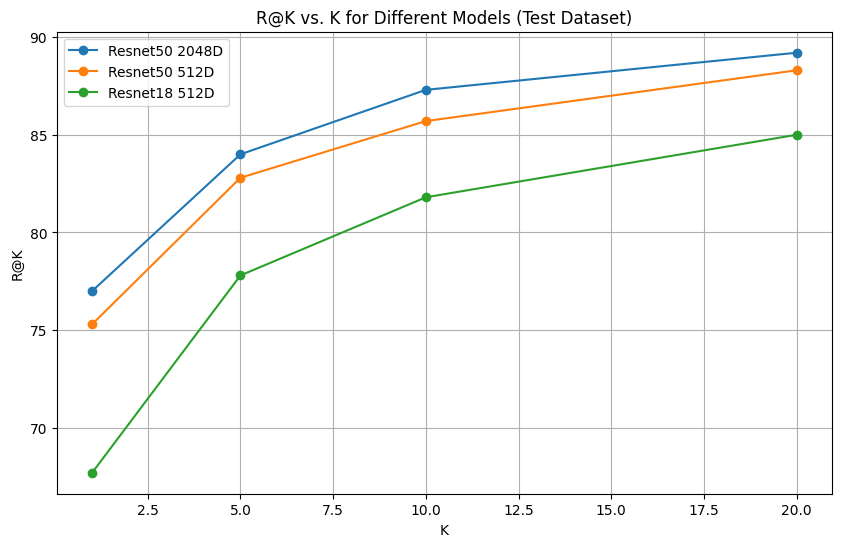

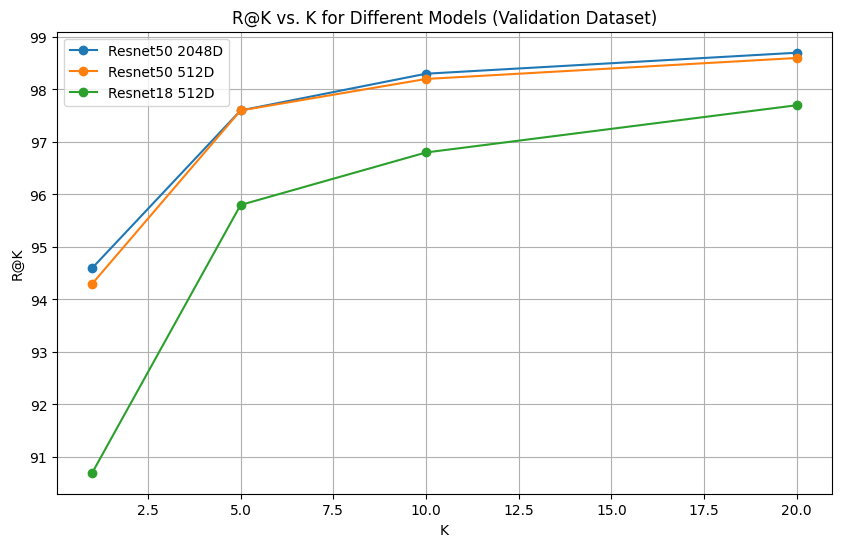

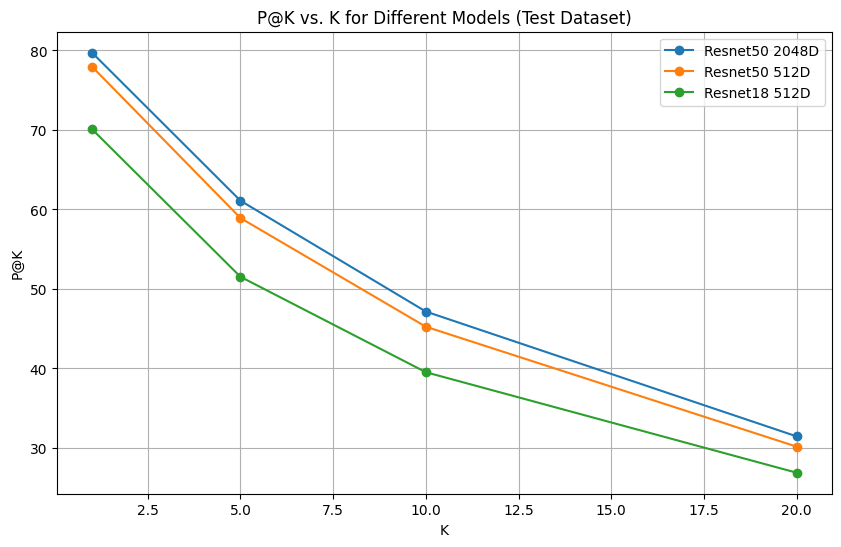

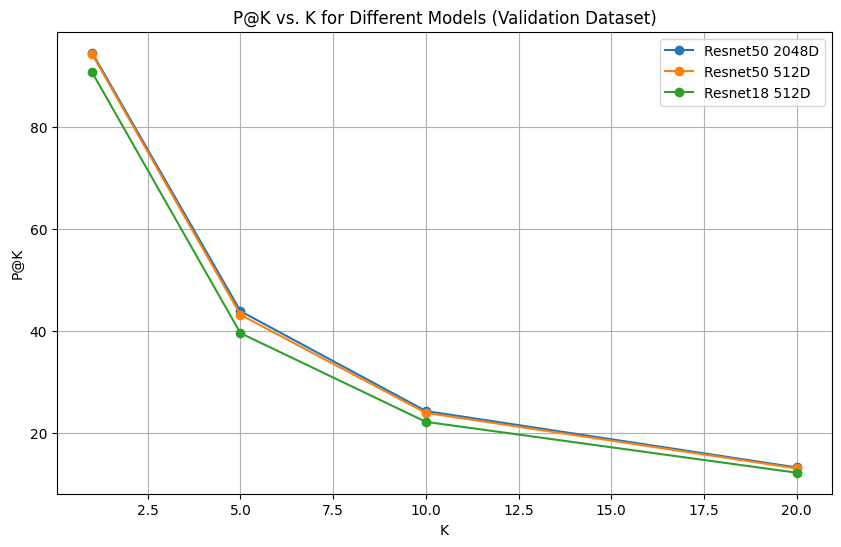

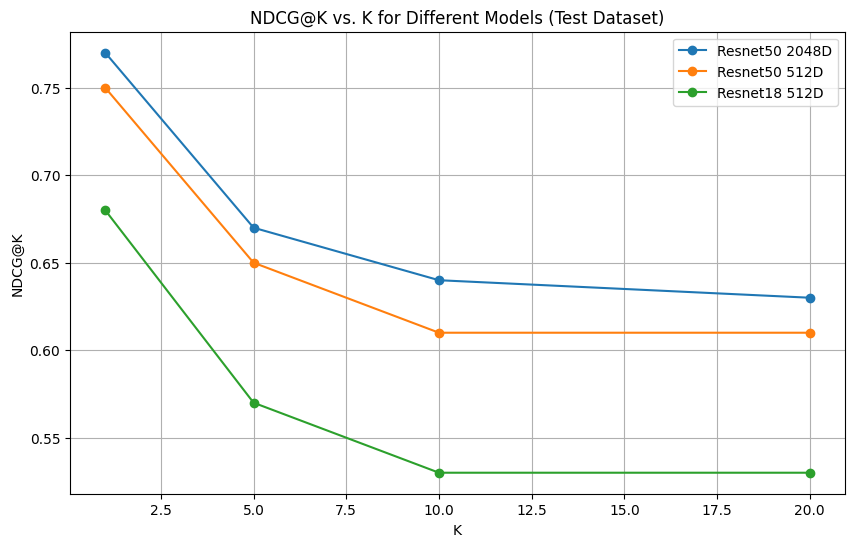

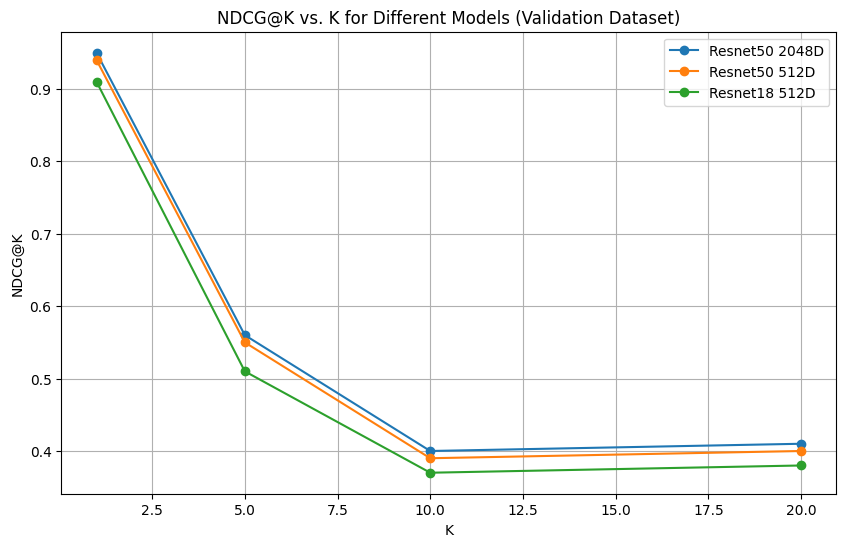

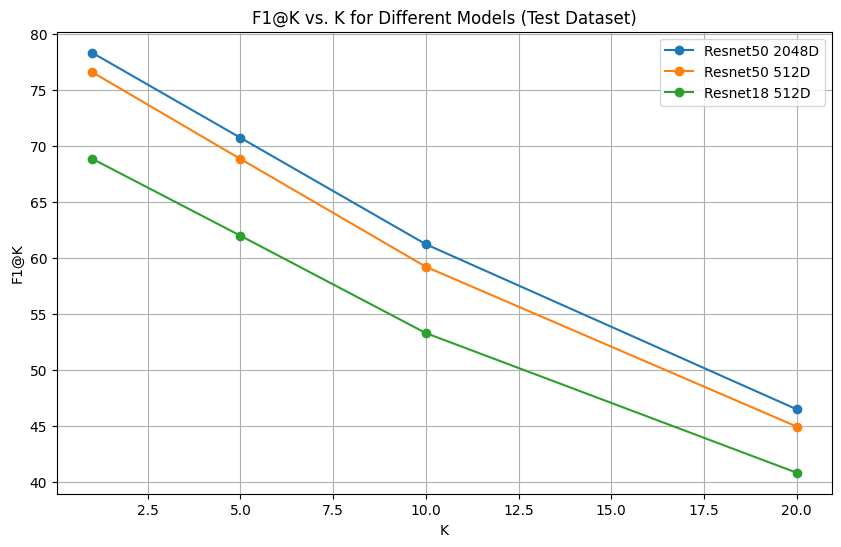

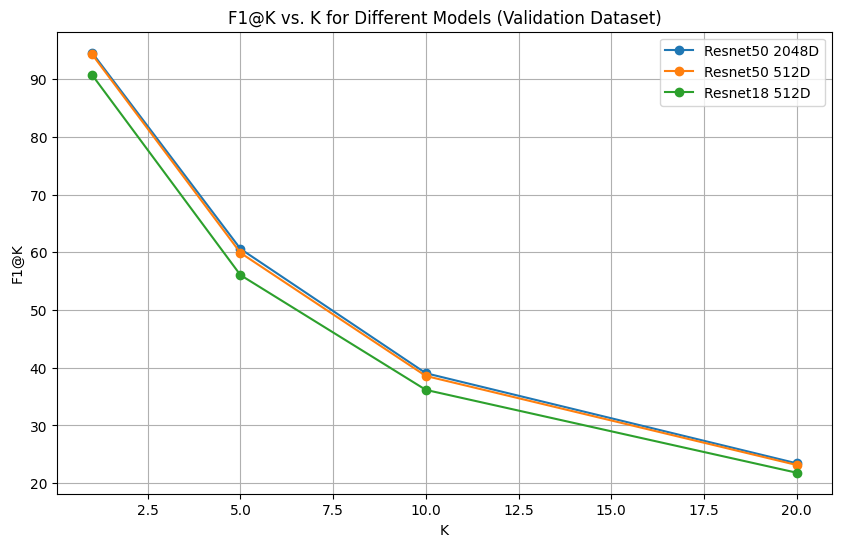

In [13]:
import matplotlib.pyplot as plt

# Data for Resnet50 2048D
resnet50_2048_test = {
    "R@K": [77.0, 84.0, 87.3, 89.2],
    "P@K": [79.71, 61.10, 47.16, 31.46],
    "NDCG@K": [0.77, 0.67, 0.64, 0.63],
    "F1@K": [78.33, 70.74, 61.24, 46.51],
}
resnet50_2048_val = {
    "R@K": [94.6, 97.6, 98.3, 98.7],
    "P@K": [94.57, 43.93, 24.36, 13.30],
    "NDCG@K": [0.95, 0.56, 0.40, 0.41],
    "F1@K": [94.57, 60.59, 39.05, 23.44],
}

# Data for Resnet50 512D
resnet50_512_test = {
    "R@K": [75.3, 82.8, 85.7, 88.3],
    "P@K": [77.95, 58.92, 45.25, 30.17],
    "NDCG@K": [0.75, 0.65, 0.61, 0.61],
    "F1@K": [76.60, 68.85, 59.23, 44.97],
}
resnet50_512_val = {
    "R@K": [94.3, 97.6, 98.2, 98.6],
    "P@K": [94.28, 43.22, 24.00, 13.12],
    "NDCG@K": [0.94, 0.55, 0.39, 0.40],
    "F1@K": [94.28, 59.90, 38.57, 23.15],
}

# Data for Resnet18 512D
resnet18_512_test = {
    "R@K": [67.7, 77.8, 81.8, 85.0],
    "P@K": [70.08, 51.53, 39.53, 26.89],
    "NDCG@K": [0.68, 0.57, 0.53, 0.53],
    "F1@K": [68.87, 62.00, 53.31, 40.85],
}
resnet18_512_val = {
    "R@K": [90.7, 95.8, 96.8, 97.7],
    "P@K": [90.72, 39.62, 22.24, 12.27],
    "NDCG@K": [0.91, 0.51, 0.37, 0.38],
    "F1@K": [90.72, 56.05, 36.16, 21.81],
}

# Function to plot metrics
def plot_metrics(data, title, metric):
    Ks = [1, 5, 10, 20]
    plt.figure(figsize=(10, 6))
    
    for model_name, values in data.items():
        plt.plot(Ks, values[metric], marker='o', label=model_name)
    
    plt.xlabel('K')
    plt.ylabel(metric)
    plt.title(f'{metric} vs. K for Different Models ({title})')
    plt.legend()
    plt.grid(True)
    plt.show()

# Data dictionaries for test and validation
test_data = {
    "Resnet50 2048D": resnet50_2048_test,
    "Resnet50 512D": resnet50_512_test,
    "Resnet18 512D": resnet18_512_test,
}

val_data = {
    "Resnet50 2048D": resnet50_2048_val,
    "Resnet50 512D": resnet50_512_val,
    "Resnet18 512D": resnet18_512_val,
}

# Plot for each metric
metrics = ["R@K", "P@K", "NDCG@K", "F1@K"]
for metric in metrics:
    plot_metrics(test_data, "Test Dataset", metric)
    plot_metrics(val_data, "Validation Dataset", metric)


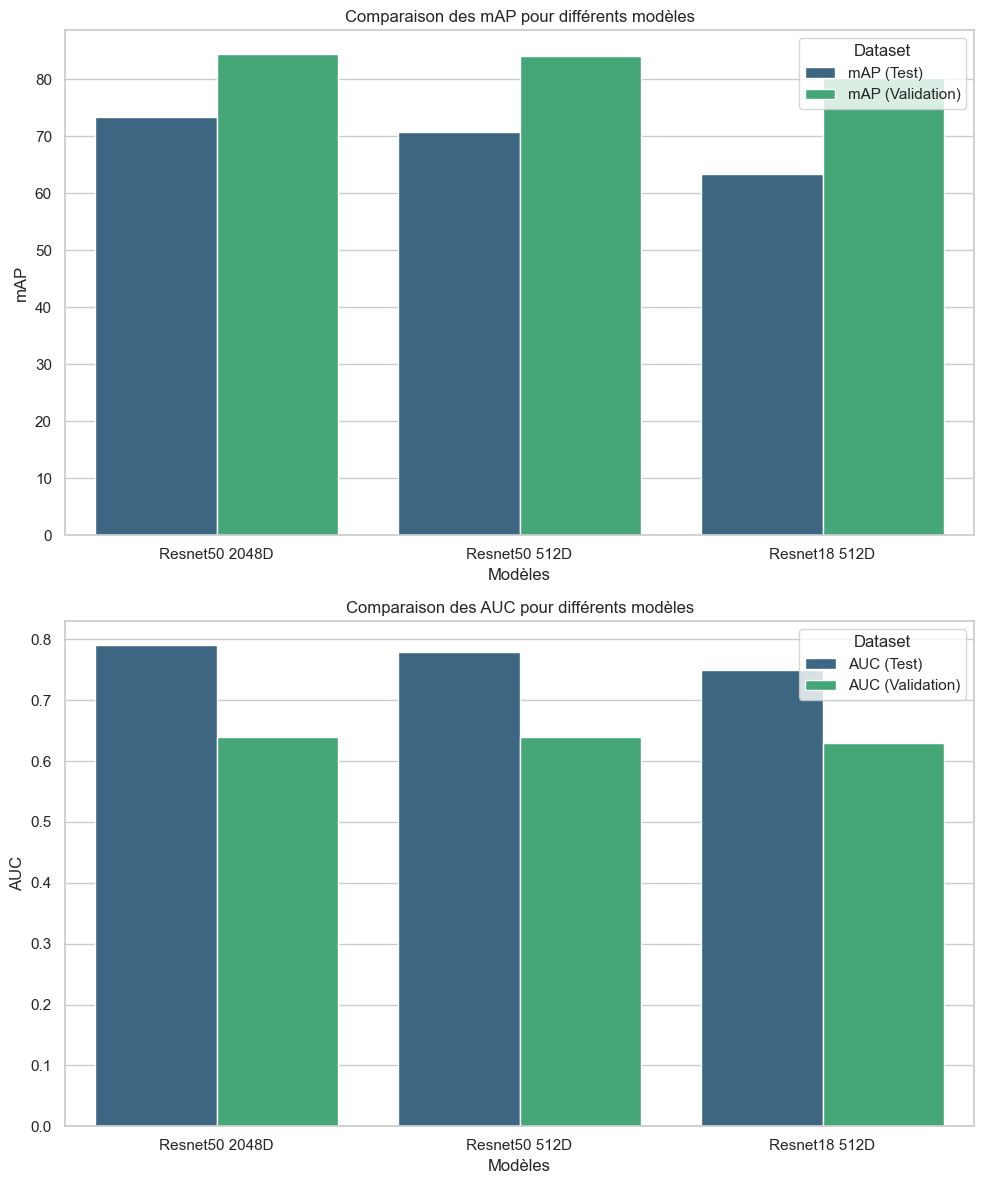

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Data for mAP and AUC
data = {
    'Model': ['Resnet50 2048D', 'Resnet50 512D', 'Resnet18 512D'],
    'mAP (Test)': [73.40, 70.68, 63.37],
    'mAP (Validation)': [84.34, 84.07, 80.25],
    'AUC (Test)': [0.79, 0.78, 0.75],
    'AUC (Validation)': [0.64, 0.64, 0.63]
}

# Convert to DataFrame
df = pd.DataFrame(data)

# Set style
sns.set(style="whitegrid")

# Create a figure with subplots
fig, axes = plt.subplots(2, 1, figsize=(10, 12))

# Plot for mAP
sns.barplot(x='Model', y='value', hue='variable', 
            data=pd.melt(df, id_vars=['Model'], value_vars=['mAP (Test)', 'mAP (Validation)']),
            ax=axes[0], palette='viridis')
axes[0].set_title('Comparaison des mAP pour différents modèles')
axes[0].set_ylabel('mAP')
axes[0].set_xlabel('Modèles')
axes[0].legend(title='Dataset')

# Plot for AUC
sns.barplot(x='Model', y='value', hue='variable', 
            data=pd.melt(df, id_vars=['Model'], value_vars=['AUC (Test)', 'AUC (Validation)']),
            ax=axes[1], palette='viridis')
axes[1].set_title('Comparaison des AUC pour différents modèles')
axes[1].set_ylabel('AUC')
axes[1].set_xlabel('Modèles')
axes[1].legend(title='Dataset')

# Adjust layout
plt.tight_layout()
plt.show()


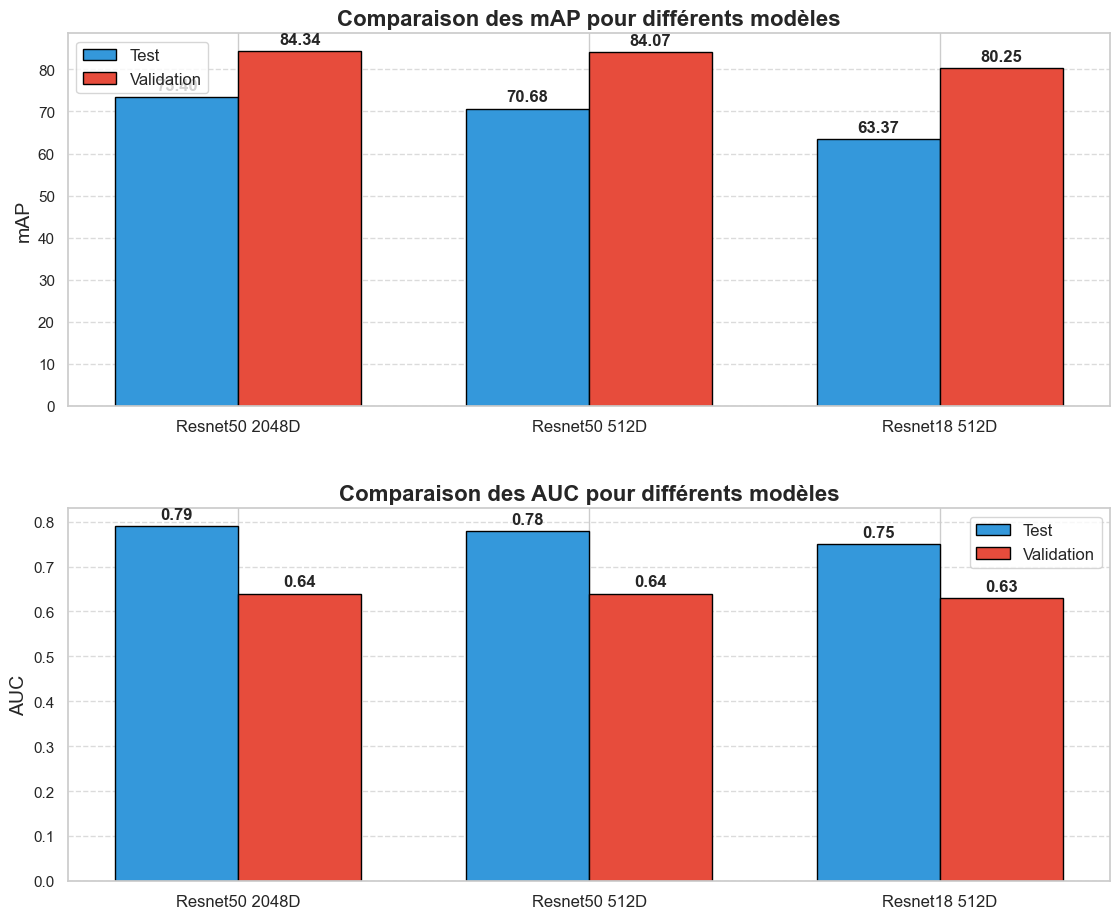

In [17]:
import matplotlib.pyplot as plt
import numpy as np

# Data for mAP and AUC
models = ['Resnet50 2048D', 'Resnet50 512D', 'Resnet18 512D']
map_test = [73.40, 70.68, 63.37]
map_validation = [84.34, 84.07, 80.25]
auc_test = [0.79, 0.78, 0.75]
auc_validation = [0.64, 0.64, 0.63]

x = np.arange(len(models))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(2, 1, figsize=(12, 10))

# Plot for mAP
rects1 = ax[0].bar(x - width/2, map_test, width, label='Test', color='#3498db', edgecolor='black')
rects2 = ax[0].bar(x + width/2, map_validation, width, label='Validation', color='#e74c3c', edgecolor='black')

ax[0].set_ylabel('mAP', fontsize=14)
ax[0].set_title('Comparaison des mAP pour différents modèles', fontsize=16, fontweight='bold')
ax[0].set_xticks(x)
ax[0].set_xticklabels(models, fontsize=12)
ax[0].legend(fontsize=12)
ax[0].grid(True, axis='y', linestyle='--', alpha=0.7)

# Plot for AUC
rects3 = ax[1].bar(x - width/2, auc_test, width, label='Test', color='#3498db', edgecolor='black')
rects4 = ax[1].bar(x + width/2, auc_validation, width, label='Validation', color='#e74c3c', edgecolor='black')

ax[1].set_ylabel('AUC', fontsize=14)
ax[1].set_title('Comparaison des AUC pour différents modèles', fontsize=16, fontweight='bold')
ax[1].set_xticks(x)
ax[1].set_xticklabels(models, fontsize=12)
ax[1].legend(fontsize=12)
ax[1].grid(True, axis='y', linestyle='--', alpha=0.7)

# Function to add labels on top of the bars
def add_labels(rects, ax):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=12, fontweight='bold')

add_labels(rects1, ax[0])
add_labels(rects2, ax[0])
add_labels(rects3, ax[1])
add_labels(rects4, ax[1])

fig.tight_layout(pad=3.0)
plt.show()
